# CRTB Simulation Study

Evaluate **crtb** (Cellwise Robust Twoblock) against **twoblock** (TB) under
two contamination regimes.

## Part 1 — Cellwise contamination
- **70 %** of rows contain at least one outlying cell (row_rate = 0.70).
- **Signal-targeted positive shifts** on individual cells of signal X
  variables (and on Y).
- This is the regime CRTB is designed for: per-cell detection lets it
  retain the clean cells in contaminated rows, instead of discarding the
  whole row.

## Part 2 — Rowwise (casewise) contamination
- Entire rows are shifted (classical leverage outliers).
- TB is expected to break down; CRTB's casewise reweighting should keep
  it on its feet.

## Sparse CRTB sparsity selection
The sparse CRTB sparsity parameter `eta` (used as `eta_x = eta_y`) is
selected per repeat by a coarse 3-fold cross-validation over the grid
`[0.3, 0.5, 0.7]`, scoring on held-out Y prediction MSE.

## Cellwise outlier detection quality
Section near the end reports precision / recall / F1 of CRTB's
column-wise prefilter (`start_cellwise='prefilter'`) for both X and Y
blocks against the known outlier mask.

In [1]:
import numpy as np
import pandas as ps
import warnings
warnings.filterwarnings('ignore')

from twoblock import twoblock, crtb

## Simulation parameters

In [2]:
# Fixed parameters
n          = 100    # observations
k          = 3      # true latent dimension (= optimal n_components_x)
q          = 4      # Y variables
sigma_e    = 0.5    # X noise std
sigma_f    = 0.5    # Y noise std
outlier_shift = 10  # positive additive contamination magnitude
n_repeats  = 200
eta_x_sim  = 0.5    # sparsity parameter for sparse methods
eta_y_sim  = 0.5

# ---- Part 1: Cellwise contamination ----
# Row contamination rate: 70 % exceeds the 50 % row-contamination point.
row_rate = 0.70
# Cell contamination levels (fraction of signal cells per affected row)
cell_cont_pcts = [0.0, 0.05, 0.10, 0.15, 0.20]

# ---- Part 2: Rowwise (casewise) contamination ----
# Fraction of rows shifted as whole observations
row_cont_pcts = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]

# Dimensionality configurations
dim_configs = {
    'p20_noise10': (20, 10),
    'p20_noise80': (20, 80),
}

print(f"n={n}, k={k}, q={q}, repeats={n_repeats}")
print(f"Outlier shift: +{outlier_shift} (positive, signal-targeted)")
print(f"\nPart 1 — Cellwise:")
print(f"  Row contamination rate: {row_rate*100:.0f}% (fixed)")
print(f"  Cell contamination levels: {[f'{c*100:.0f}%' for c in cell_cont_pcts]}")
print(f"\nPart 2 — Rowwise:")
print(f"  Row contamination levels: {[f'{c*100:.0f}%' for c in row_cont_pcts]}")
print(f"\nDimensionality configs:")
for label, (ps_, pn) in dim_configs.items():
    print(f"  {label}: p_signal={ps_}, p_noise={pn}, p_total={ps_+pn}")

n=100, k=3, q=4, repeats=200
Outlier shift: +10 (positive, signal-targeted)

Part 1 — Cellwise:
  Row contamination rate: 70% (fixed)
  Cell contamination levels: ['0%', '5%', '10%', '15%', '20%']

Part 2 — Rowwise:
  Row contamination levels: ['0%', '5%', '10%', '15%', '20%', '25%']

Dimensionality configs:
  p20_noise10: p_signal=20, p_noise=10, p_total=30
  p20_noise80: p_signal=20, p_noise=80, p_total=100


## Data generation and contamination functions

In [3]:
def generate_clean_data(rng, n, p_signal, p_noise, k, q, sigma_e, sigma_f):
    """
    Generate clean two-block data from a latent variable model.

    X = T @ P_signal.T + E   (n x p, p = p_signal + p_noise)
    Y = T @ C + F            (n x q)
    B_true = [P_signal @ C; 0]  (p x q)

    P_signal is orthonormal (from QR), T ~ N(0,I), E ~ N(0, sigma_e^2 I),
    F ~ N(0, sigma_f^2 I), C ~ N(0,I).
    """
    p = p_signal + p_noise

    T = rng.standard_normal((n, k))

    P_raw = rng.standard_normal((p_signal, k))*3
    P_signal, _ = np.linalg.qr(P_raw)
    P_signal = P_signal[:, :k]

    C = rng.standard_normal((k, q))

    E = sigma_e * rng.standard_normal((n, p_signal))
    X_signal = T @ P_signal.T + E/10

    if p_noise > 0:
        X_noise = sigma_e * rng.standard_normal((n, p_noise))
        X = np.hstack([X_signal, X_noise])
    else:
        X = X_signal

    F = sigma_f * rng.standard_normal((n, q))/10
    Y = T @ C + F

    B_true = np.zeros((p, q))
    B_true[:p_signal, :] = P_signal @ C

    return X, Y, B_true


def add_cellwise_outliers_block(Z, cell_cont_pct, outlier_shift, rng, row_rate=0.70,
                               signal_cols=None):
    """
    Add cellwise outliers to a data block Z (n x d).

    Signal-targeted positive shifts: contamination is applied only to
    signal columns (or all columns if signal_cols is None).  Shifts are
    positive-only, modelling realistic contamination (sensor drift,
    baseline shift, additive interference) that corrupts column means.

    Parameters
    ----------
    Z : ndarray (n, d)
    cell_cont_pct : float
        Fraction of signal cells per affected row to contaminate.
    outlier_shift : float
        Additive positive shift.
    rng : numpy Generator
    row_rate : float
        Fraction of rows to contaminate.
    signal_cols : int or None
        Number of signal columns (0..signal_cols-1).  If None, all columns.

    Returns Z_cont (contaminated copy) and outlier_mask (bool, n x d).
    """
    if cell_cont_pct == 0.0:
        return Z.copy(), np.zeros(Z.shape, dtype=bool)

    n, d = Z.shape
    sig = signal_cols if signal_cols is not None else d
    cells_per_row = cell_cont_pct * sig / row_rate

    Z_cont = Z.copy()
    outlier_mask = np.zeros((n, d), dtype=bool)

    n_cont_rows = int(np.ceil(n * row_rate))
    cont_rows = rng.choice(n, size=n_cont_rows, replace=False)

    for row in cont_rows:
        n_cells = max(1, min(sig, rng.poisson(cells_per_row)))
        cont_cols = rng.choice(sig, size=n_cells, replace=False)
        Z_cont[row, cont_cols] += outlier_shift  # positive only
        outlier_mask[row, cont_cols] = True

    return Z_cont, outlier_mask


def mse_B(B_est, B_true):
    """Mean squared error per element of the coefficient matrix."""
    return np.mean((B_est - B_true) ** 2)


def f1_score(indret, p_signal, p):
    """
    F1 score for X variable selection.

    Signal variables are indices 0 .. p_signal-1;
    noise variables are p_signal .. p-1.
    `indret` is the array of selected column indices (from x_indret_).
    """
    selected = set(indret.tolist())
    signal   = set(range(p_signal))
    tp = len(selected & signal)
    fp = len(selected - signal)
    fn = len(signal - selected)
    denom = 2 * tp + fp + fn
    return (2 * tp / denom) if denom > 0 else 0.0

def add_rowwise_outliers(X, Y, row_cont_pct, outlier_shift, rng, signal_cols=None):
    """
    Add rowwise (casewise) outliers: shift all variables in selected rows.

    Parameters
    ----------
    X : ndarray (n, p)
    Y : ndarray (n, q)
    row_cont_pct : float
        Fraction of rows to contaminate.
    outlier_shift : float
        Additive positive shift.
    rng : numpy Generator
    signal_cols : int or None
        Number of X signal columns.  If None, shift all X columns.

    Returns Xc, Yc (contaminated copies) and outlier_rows (bool array).
    """
    if row_cont_pct == 0.0:
        return X.copy(), Y.copy(), np.zeros(X.shape[0], dtype=bool)

    n = X.shape[0]
    sig = signal_cols if signal_cols is not None else X.shape[1]
    n_cont = int(np.ceil(n * row_cont_pct))
    cont_rows = rng.choice(n, size=n_cont, replace=False)

    Xc = X.copy()
    Yc = Y.copy()
    outlier_rows = np.zeros(n, dtype=bool)
    outlier_rows[cont_rows] = True

    Xc[cont_rows, :sig] += outlier_shift  # positive shift on signal cols
    Yc[cont_rows, :]    += outlier_shift  # positive shift on all Y cols

    return Xc, Yc, outlier_rows


## Verify contamination design

In [4]:
rng_check = np.random.default_rng(42)
X_chk, Y_chk, _ = generate_clean_data(rng_check, n=100, p_signal=20, p_noise=10,
                                        k=3, q=4, sigma_e=0.5, sigma_f=0.5)

print(f"{'Cell cont. target':>20} {'Actual X cells':>16} {'Actual X rows':>14} {'Actual Y cells':>16} {'Actual Y rows':>14}")
print("-" * 85)
for ccp in [0.05, 0.10, 0.15, 0.20]:
    rng_v = np.random.default_rng(0)
    Xc, mx = add_cellwise_outliers_block(X_chk, ccp, 10.0, rng_v, row_rate=0.70, signal_cols=20)
    Yc, my = add_cellwise_outliers_block(Y_chk, ccp, 10.0, rng_v, row_rate=0.70)
    xc_pct = 100 * mx.sum() / mx.size
    xr_pct = 100 * mx.any(axis=1).sum() / mx.shape[0]
    yc_pct = 100 * my.sum() / my.size
    yr_pct = 100 * my.any(axis=1).sum() / my.shape[0]
    print(f"{ccp*100:>18.0f}% {xc_pct:>14.1f}% {xr_pct:>12.0f}% {yc_pct:>14.1f}% {yr_pct:>12.0f}%")

print("\nNote: X contamination targets signal columns only (positive shifts).")
print("Y contamination targets all columns (positive shifts).")

   Cell cont. target   Actual X cells  Actual X rows   Actual Y cells  Actual Y rows
-------------------------------------------------------------------------------------
                 5%            4.2%           70%           18.5%           70%
                10%            7.7%           70%           19.8%           70%
                15%           10.3%           70%           23.8%           70%
                20%           13.3%           70%           23.5%           70%

Note: X contamination targets signal columns only (positive shifts).
Y contamination targets all columns (positive shifts).


## Single-repeat runner

In [5]:
# Shared Hampel cutoffs — relaxed to handle heavy contamination
_probp1, _probp2, _probp3 = 0.75, 0.90, 0.95

# Coarse CV grid for sparse CRTB sparsity parameter
_eta_grid = [0.3, 0.5, 0.7]
_cv_n_folds = 3


def run_single_cellwise(rng, n, p_signal, p_noise, k, q, sigma_e, sigma_f,
                        cell_cont_pct, outlier_shift, row_rate=0.70):
    """
    Run one simulation repeat under cellwise contamination.
    """
    X, Y, B_true = generate_clean_data(rng, n, p_signal, p_noise, k, q, sigma_e, sigma_f)
    Xc, mask_x = add_cellwise_outliers_block(X, cell_cont_pct, outlier_shift, rng, row_rate,
                                              signal_cols=p_signal)
    Yc, mask_y = add_cellwise_outliers_block(Y, cell_cont_pct, outlier_shift, rng, row_rate)

    return _fit_all_methods(Xc, Yc, B_true, p_signal, p_noise, k, q,
                            true_mask_x=mask_x, true_mask_y=mask_y)


def run_single_rowwise(rng, n, p_signal, p_noise, k, q, sigma_e, sigma_f,
                       row_cont_pct, outlier_shift):
    """
    Run one simulation repeat under rowwise (casewise) contamination.
    """
    X, Y, B_true = generate_clean_data(rng, n, p_signal, p_noise, k, q, sigma_e, sigma_f)
    Xc, Yc, _ = add_rowwise_outliers(X, Y, row_cont_pct, outlier_shift, rng,
                                      signal_cols=p_signal)

    return _fit_all_methods(Xc, Yc, B_true, p_signal, p_noise, k, q)


def _cell_detection_metrics(detected, true_mask):
    """
    Compute cell-level detection TP, FP, FN, precision, recall, F1.
    """
    tp = int(np.sum(detected & true_mask))
    fp = int(np.sum(detected & ~true_mask))
    fn = int(np.sum(~detected & true_mask))
    prec = tp / max(tp + fp, 1)
    rec  = tp / max(tp + fn, 1)
    f1   = 2 * prec * rec / max(prec + rec, 1e-12)
    return tp, fp, fn, prec, rec, f1


def _cv_select_eta_crtb(X, Y, k, nc_y, eta_grid, n_folds, **crtb_kwargs):
    """
    Coarse k-fold CV to select the sparsity parameter for sparse CRTB.

    Same eta is used for both eta_x and eta_y. Selection criterion: held-out
    Y prediction MSE averaged across folds.
    """
    n = X.shape[0]
    rng = np.random.default_rng(0)
    fold_ids = rng.permutation(n) % n_folds

    best_eta   = eta_grid[0]
    best_score = np.inf
    for eta in eta_grid:
        cv_mses = []
        for fold in range(n_folds):
            test  = (fold_ids == fold)
            train = ~test
            try:
                m = crtb(n_components_x=k, n_components_y=nc_y,
                         sparse=True, eta_x=eta, eta_y=eta,
                         verbose=False, copy=False, **crtb_kwargs)
                m.fit(X[train], Y[train])
                Y_pred = m.predict(X[test])
                cv_mses.append(float(np.mean((Y[test] - Y_pred) ** 2)))
            except Exception:
                cv_mses.append(np.inf)
        score = float(np.nanmean(cv_mses))
        if score < best_score:
            best_score = score
            best_eta   = eta
    return best_eta


def _cv_select_eta_tb(X, Y, k, nc_y, eta_grid, n_folds):
    """
    Coarse k-fold CV to select the sparsity parameter for sparse TB.

    Same eta is used for both eta_x and eta_y. Selection criterion: held-out
    Y prediction MSE averaged across folds.
    """
    n = X.shape[0]
    rng = np.random.default_rng(0)
    fold_ids = rng.permutation(n) % n_folds

    best_eta   = eta_grid[0]
    best_score = np.inf
    for eta in eta_grid:
        cv_mses = []
        for fold in range(n_folds):
            test  = (fold_ids == fold)
            train = ~test
            try:
                m = twoblock(n_components_x=k, n_components_y=nc_y,
                             sparse=True, eta_x=eta, eta_y=eta,
                             scale='std', verbose=False, copy=False)
                m.fit(X[train], Y[train])
                Y_pred = m.predict(X[test])
                cv_mses.append(float(np.mean((Y[test] - Y_pred) ** 2)))
            except Exception:
                cv_mses.append(np.inf)
        score = float(np.nanmean(cv_mses))
        if score < best_score:
            best_score = score
            best_eta   = eta
    return best_eta


def _fit_all_methods(Xc, Yc, B_true, p_signal, p_noise, k, q,
                     true_mask_x=None, true_mask_y=None):
    """
    Fit all four methods (dense + sparse × TB + CRTB) and return MSE/F1.
    Sparse CRTB selects its sparsity parameter via coarse k-fold CV.
    When true_mask_x/y are provided, also return cell-detection metrics for CRTB.
    """
    p        = p_signal + p_noise
    has_noise = p_noise > 0
    nc_y     = min(k, q)
    res      = {}

    # ---- twoblock dense ----
    try:
        tb = twoblock(n_components_x=k, n_components_y=nc_y,
                      scale='std', verbose=False, copy=False)
        tb.fit(Xc, Yc)
        res['tb_mse']  = mse_B(tb.coef_, B_true)
    except Exception:
        res['tb_mse']  = np.nan

    # ---- twoblock sparse (coarse CV over eta) ----
    try:
        best_eta_tb = _cv_select_eta_tb(Xc, Yc, k, nc_y, _eta_grid, _cv_n_folds)
        tbs = twoblock(n_components_x=k, n_components_y=nc_y,
                       sparse=True, eta_x=best_eta_tb, eta_y=best_eta_tb,
                       scale='std', verbose=False, copy=False)
        tbs.fit(Xc, Yc)
        res['tbs_mse'] = mse_B(tbs.coef_, B_true)
        res['tbs_f1']  = f1_score(tbs.x_indret_, p_signal, p) if has_noise else np.nan
        res['tbs_eta'] = best_eta_tb
    except Exception:
        res['tbs_mse'] = np.nan
        res['tbs_f1']  = np.nan
        res['tbs_eta'] = np.nan

    # ---- crtb dense (median + mad, prefilter starting values) ----
    try:
        cr = crtb(n_components_x=k, n_components_y=nc_y,
                  centre='median', scale='mad', verbose=False, copy=False,
                  probp1=_probp1, probp2=_probp2, probp3=_probp3,
                  start_cellwise='prefilter',
                  crit_cellwise=0.99, maxit=25)
        cr.fit(Xc, Yc)
        res['crtb_mse'] = mse_B(cr.coef_, B_true)
        # Cell detection metrics
        if true_mask_x is not None:
            det_x = cr.x_cellwise_outliers_
            tp, fp, fn, prec, rec, f1 = _cell_detection_metrics(det_x, true_mask_x)
            res['cell_tp_x']   = tp
            res['cell_fp_x']   = fp
            res['cell_fn_x']   = fn
            res['cell_prec_x'] = prec
            res['cell_rec_x']  = rec
            res['cell_f1_x']   = f1
        if true_mask_y is not None:
            det_y = cr.y_cellwise_outliers_
            tp, fp, fn, prec, rec, f1 = _cell_detection_metrics(det_y, true_mask_y)
            res['cell_tp_y']   = tp
            res['cell_fp_y']   = fp
            res['cell_fn_y']   = fn
            res['cell_prec_y'] = prec
            res['cell_rec_y']  = rec
            res['cell_f1_y']   = f1
    except Exception:
        res['crtb_mse'] = np.nan

    # ---- crtb sparse (median + mad, prefilter, coarse CV over eta) ----
    try:
        crtb_kwargs = dict(centre='median', scale='mad',
                           probp1=_probp1, probp2=_probp2, probp3=_probp3,
                           start_cellwise='prefilter',
                           crit_cellwise=0.99, maxit=25)
        best_eta = _cv_select_eta_crtb(Xc, Yc, k, nc_y, _eta_grid, _cv_n_folds,
                                       **crtb_kwargs)
        crs = crtb(n_components_x=k, n_components_y=nc_y,
                   sparse=True, eta_x=best_eta, eta_y=best_eta,
                   verbose=False, copy=False, **crtb_kwargs)
        crs.fit(Xc, Yc)
        res['crtbs_mse'] = mse_B(crs.coef_, B_true)
        res['crtbs_f1']  = f1_score(crs.x_indret_, p_signal, p) if has_noise else np.nan
        res['crtbs_eta'] = best_eta
    except Exception:
        res['crtbs_mse'] = np.nan
        res['crtbs_f1']  = np.nan
        res['crtbs_eta'] = np.nan

    return res


## Part 1 — Cellwise contamination: main simulation loop

Iterates over all (dim_config × cell_cont_pct) scenarios, running `n_repeats` repeats each.

In [6]:
import time

rng = np.random.default_rng(42)

metrics = ['tb_mse', 'crtb_mse',
           'tbs_mse', 'crtbs_mse',
           'tbs_f1', 'crtbs_f1', 'tbs_eta', 'crtbs_eta',
           'cell_tp_x', 'cell_fp_x', 'cell_fn_x',
           'cell_prec_x', 'cell_rec_x', 'cell_f1_x',
           'cell_tp_y', 'cell_fp_y', 'cell_fn_y',
           'cell_prec_y', 'cell_rec_y', 'cell_f1_y']

scenarios_cw = [
    (dim_label, p_signal, p_noise, ccp)
    for dim_label, (p_signal, p_noise) in dim_configs.items()
    for ccp in cell_cont_pcts
]

print(f"Total scenarios : {len(scenarios_cw)}")
print(f"Fits per scenario: {n_repeats} repeats × 4 methods = {n_repeats * 4}")

all_results_cw = []
t0 = time.time()

for si, (dim_label, p_signal, p_noise, ccp) in enumerate(scenarios_cw):
    collected = {m: [] for m in metrics}

    for rep in range(n_repeats):
        res = run_single_cellwise(rng, n, p_signal, p_noise, k, q, sigma_e, sigma_f,
                                  ccp, outlier_shift, row_rate)
        for m in metrics:
            collected[m].append(res.get(m, np.nan))

    row = {
        'dim_config':    dim_label,
        'p_signal':      p_signal,
        'p_noise':       p_noise,
        'p_total':       p_signal + p_noise,
        'cell_cont_pct': ccp,
    }
    for m in metrics:
        arr = np.array(collected[m])
        row[f'{m}_mean'] = np.nanmean(arr)
        row[f'{m}_sd']   = np.nanstd(arr)
    all_results_cw.append(row)

    elapsed = time.time() - t0
    det_info = ''
    if ccp > 0:
        det_info = (f"  X: prec={row['cell_prec_x_mean']:.2f} rec={row['cell_rec_x_mean']:.2f} "
                    f"F1={row['cell_f1_x_mean']:.2f}"
                    f"  Y: prec={row['cell_prec_y_mean']:.2f} rec={row['cell_rec_y_mean']:.2f} "
                    f"F1={row['cell_f1_y_mean']:.2f}")
    print(f"  [{si+1:2d}/{len(scenarios_cw)}] {dim_label}, cont={ccp*100:.0f}%  "
          f"TB={row['tb_mse_mean']:.4f}  "
          f"CRTB={row['crtb_mse_mean']:.4f}  "
          f"CRTBs eta(avg)={row['crtbs_eta_mean']:.2f}{det_info}  ({elapsed:.0f}s)",
          flush=True)

print(f"\nDone in {time.time()-t0:.0f}s")

Total scenarios : 10
Fits per scenario: 200 repeats × 4 methods = 800
  [ 1/10] p20_noise10, cont=0%  TB=0.0928  CRTB=0.0907  CRTBs eta(avg)=0.30  (87s)
  [ 2/10] p20_noise10, cont=5%  TB=0.2305  CRTB=0.0778  CRTBs eta(avg)=0.30  X: prec=0.80 rec=1.00 F1=0.89  Y: prec=0.99 rec=0.88 F1=0.92  (205s)
  [ 3/10] p20_noise10, cont=10%  TB=0.2253  CRTB=0.0775  CRTBs eta(avg)=0.30  X: prec=0.90 rec=1.00 F1=0.95  Y: prec=0.99 rec=0.88 F1=0.93  (352s)
  [ 4/10] p20_noise10, cont=15%  TB=0.2362  CRTB=0.0820  CRTBs eta(avg)=0.30  X: prec=0.94 rec=1.00 F1=0.97  Y: prec=1.00 rec=0.83 F1=0.90  (503s)
  [ 5/10] p20_noise10, cont=20%  TB=0.2527  CRTB=0.1096  CRTBs eta(avg)=0.30  X: prec=0.96 rec=1.00 F1=0.98  Y: prec=1.00 rec=0.77 F1=0.86  (698s)
  [ 6/10] p20_noise80, cont=0%  TB=0.0256  CRTB=0.0258  CRTBs eta(avg)=0.30  (1163s)
  [ 7/10] p20_noise80, cont=5%  TB=0.1592  CRTB=0.0280  CRTBs eta(avg)=0.30  X: prec=0.49 rec=1.00 F1=0.66  Y: prec=0.99 rec=0.88 F1=0.93  (2128s)
  [ 8/10] p20_noise80, cont=

## Part 1 — Results table (cellwise)

In [7]:
df_cw = ps.DataFrame(all_results_cw)

# Format helper: mean (sd)
def fmt(df, col):
    return df.apply(lambda r: f"{r[col+'_mean']:.4f} ({r[col+'_sd']:.4f})", axis=1)

# MSE table
print("=== MSE(B): mean (sd) over", n_repeats, "repeats ===")
mse_table = df_cw[['dim_config', 'p_total', 'cell_cont_pct']].copy()
mse_table['cell_cont_pct'] = (mse_table['cell_cont_pct'] * 100).astype(int).astype(str) + '%'
for label, col in [('TB',    'tb_mse'),  ('CRTB',  'crtb_mse'),
                   ('TBs',   'tbs_mse'), ('CRTBs', 'crtbs_mse')]:
    mse_table[label] = fmt(df_cw, col)
display(mse_table)

# F1 table — sparse methods, noise configs only
noise_mask = df_cw['p_noise'] > 0
print("\n=== Variable selection F1: sparse methods, configs with noise variables ===")
f1_table = df_cw.loc[noise_mask, ['dim_config', 'p_signal', 'p_noise', 'cell_cont_pct']].copy()
f1_table['cell_cont_pct'] = (f1_table['cell_cont_pct'] * 100).astype(int).astype(str) + '%'
for label, col in [('TBs F1', 'tbs_f1'), ('CRTBs F1', 'crtbs_f1')]:
    f1_table[label] = fmt(df_cw.loc[noise_mask], col)
f1_table['TBs eta (avg)']  = df_cw.loc[noise_mask, 'tbs_eta_mean'].round(3)
f1_table['CRTBs eta (avg)'] = df_cw.loc[noise_mask, 'crtbs_eta_mean'].round(3)
display(f1_table)

=== MSE(B): mean (sd) over 200 repeats ===


,dim_config,p_total,cell_cont_pct,TB,CRTB,TBs,CRTBs
0,p20_noise10,30,0%,0.0928 (0.0698),0.0907 (0.0680),0.0971 (0.0741),0.0955 (0.0729)
1,p20_noise10,30,5%,0.2305 (0.0755),0.0778 (0.0503),0.2251 (0.0969),0.0797 (0.0503)
2,p20_noise10,30,10%,0.2253 (0.0589),0.0775 (0.0567),0.2186 (0.0588),0.0820 (0.0634)
3,p20_noise10,30,15%,0.2362 (0.0618),0.0820 (0.0579),0.2280 (0.0607),0.0818 (0.0571)
4,p20_noise10,30,20%,0.2527 (0.0672),0.1096 (0.0839),0.2460 (0.0653),0.1081 (0.0807)
5,p20_noise80,100,0%,0.0256 (0.0177),0.0258 (0.0194),0.0304 (0.0221),0.0300 (0.0242)
6,p20_noise80,100,5%,0.1592 (0.0221),0.0280 (0.0196),0.1569 (0.0224),0.0274 (0.0182)
7,p20_noise80,100,10%,0.1646 (0.0252),0.0312 (0.0227),0.1628 (0.0253),0.0299 (0.0217)
8,p20_noise80,100,15%,0.1684 (0.0279),0.0398 (0.0278),0.1658 (0.0284),0.0366 (0.0264)
9,p20_noise80,100,20%,0.1819 (0.0320),0.0609 (0.0362),0.1800 (0.0310),0.0549 (0.0324)



=== Variable selection F1: sparse methods, configs with noise variables ===


,dim_config,p_signal,p_noise,cell_cont_pct,TBs F1,CRTBs F1,TBs eta (avg),CRTBs eta (avg)
0,p20_noise10,20,10,0%,0.9666 (0.0454),0.9604 (0.0467),0.3,0.3
1,p20_noise10,20,10,5%,0.7735 (0.0407),0.9312 (0.0482),0.3,0.3
2,p20_noise10,20,10,10%,0.7636 (0.0412),0.9177 (0.0547),0.3,0.3
3,p20_noise10,20,10,15%,0.7608 (0.0478),0.8905 (0.0491),0.3,0.3
4,p20_noise10,20,10,20%,0.7592 (0.0430),0.8568 (0.0461),0.3,0.3
5,p20_noise80,20,80,0%,0.7201 (0.1950),0.7088 (0.1864),0.3,0.3
6,p20_noise80,20,80,5%,0.3319 (0.0312),0.6161 (0.1397),0.3,0.3
7,p20_noise80,20,80,10%,0.3255 (0.0332),0.5636 (0.1164),0.3,0.3
8,p20_noise80,20,80,15%,0.3262 (0.0333),0.5047 (0.0860),0.3,0.3
9,p20_noise80,20,80,20%,0.3277 (0.0321),0.4516 (0.0676),0.3,0.3


## Part 1 — Visualisation: MSE bar charts (cellwise)

One panel per dimensionality configuration; bars grouped by contamination level.

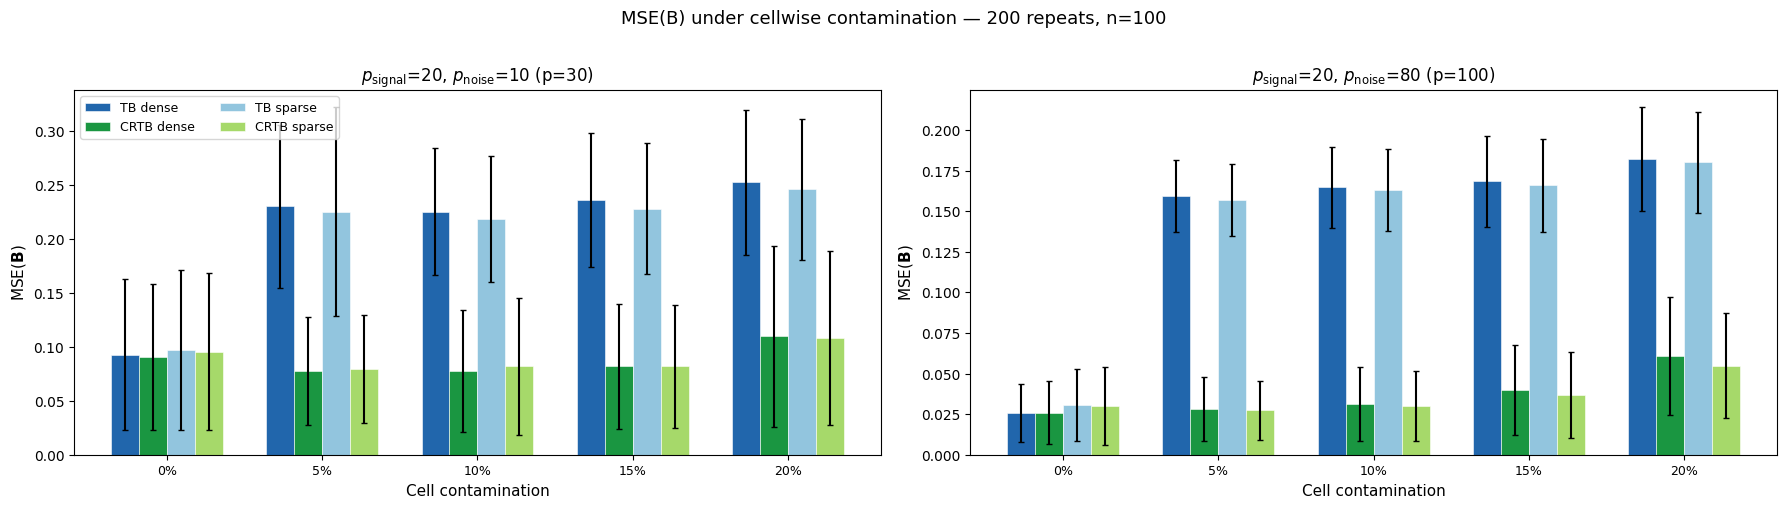

In [8]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 10, 'legend.fontsize': 9,
})

colors_4 = {
    'TB dense':    '#2166ac',
    'CRTB dense':  '#1a9641',
    'TB sparse':   '#92c5de',
    'CRTB sparse': '#a6d96a',
}

methods_dense  = [('TB dense',   'tb_mse'),  ('CRTB dense',  'crtb_mse')]
methods_sparse = [('TB sparse',  'tbs_mse'), ('CRTB sparse', 'crtbs_mse')]
all_methods = methods_dense + methods_sparse

cont_labels = [f"{int(c*100)}%" for c in cell_cont_pcts]

n_configs = len(dim_configs)
fig, axes = plt.subplots(1, n_configs, figsize=(9 * n_configs, 5), sharey=False)
if n_configs == 1:
    axes = [axes]
else:
    axes = list(axes)

for ax_idx, (dim_label, (p_signal, p_noise)) in enumerate(dim_configs.items()):
    ax = axes[ax_idx]
    sub = df_cw[df_cw['dim_config'] == dim_label].copy()

    x = np.arange(len(cell_cont_pcts))
    n_methods = len(all_methods)
    width = 0.18

    for i, (label, col) in enumerate(all_methods):
        offset = (i - (n_methods - 1) / 2) * width
        vals = sub[f'{col}_mean'].values
        errs = sub[f'{col}_sd'].values
        ax.bar(x + offset, vals, width, yerr=errs, label=label,
               color=colors_4[label], edgecolor='white', linewidth=0.4, capsize=2)

    ax.set_xticks(x)
    ax.set_xticklabels(cont_labels)
    ax.set_xlabel('Cell contamination')
    ax.set_ylabel('MSE($\\mathbf{B}$)')
    ax.set_title(f'$p_{{\\rm signal}}$={p_signal}, $p_{{\\rm noise}}$={p_noise} (p={p_signal+p_noise})')
    if ax_idx == 0:
        ax.legend(loc='upper left', ncol=2)

fig.suptitle(f'MSE(B) under cellwise contamination — {n_repeats} repeats, n={n}', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('simulation_crtb_mse_bars.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 1 — Heatmap: CRTB/TB MSE ratios (cellwise)

Values < 1 (green) indicate CRTB outperforms TB.

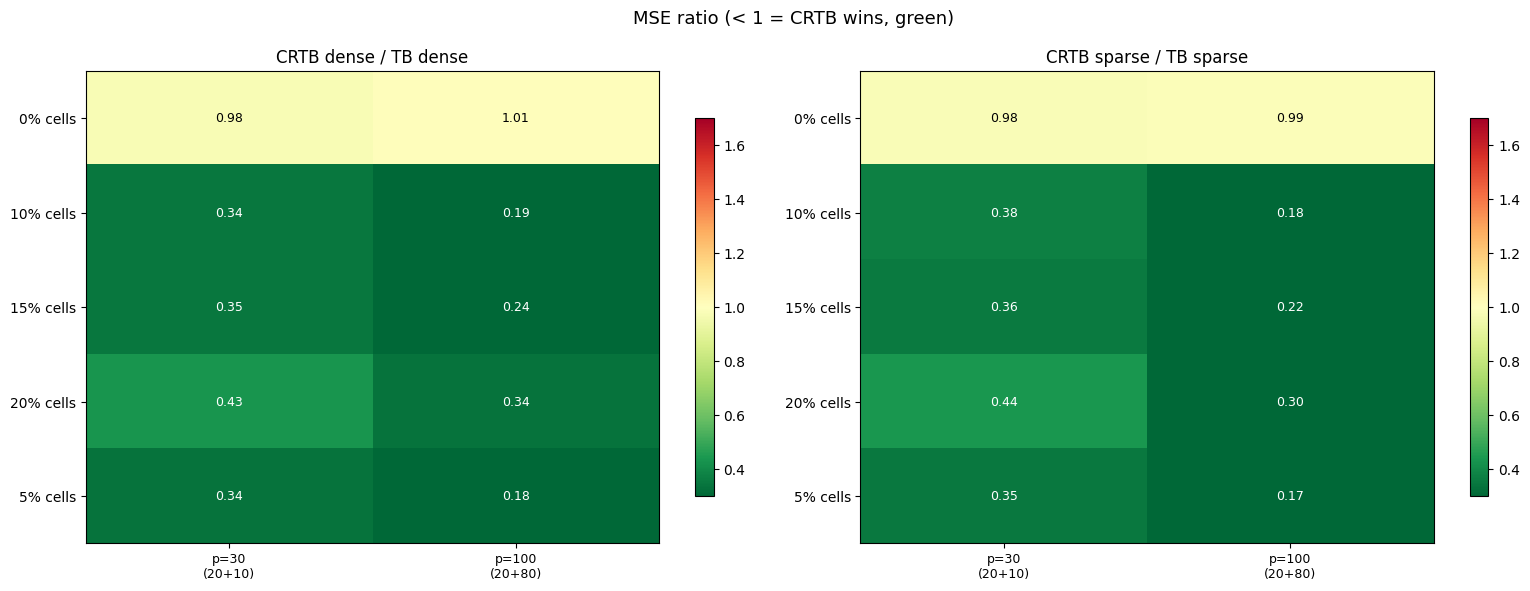

In [9]:
df_cw['CRTB/TB_dense']    = (df_cw['crtb_mse_mean']  / df_cw['tb_mse_mean']).round(3)
df_cw['CRTBs/TBs_sparse'] = (df_cw['crtbs_mse_mean'] / df_cw['tbs_mse_mean']).round(3)

df_cw['scenario'] = df_cw['cell_cont_pct'].apply(lambda c: f"{int(c*100)}% cells")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, title in [
    (axes[0], 'CRTB/TB_dense',    'CRTB dense / TB dense'),
    (axes[1], 'CRTBs/TBs_sparse', 'CRTB sparse / TB sparse'),
]:
    pivot = df_cw.pivot_table(index='scenario', columns='dim_config', values=col)
    pivot = pivot[[c for c in dim_configs if c in pivot.columns]]

    col_labels = []
    for c in pivot.columns:
        ps_, pn = dim_configs[c]
        col_labels.append(f"p={ps_+pn}\n({ps_}+{pn})")

    im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=0.3, vmax=1.7)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(col_labels, fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=10)
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax, shrink=0.8)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=9,
                        color='black' if 0.6 < val < 1.4 else 'white')

fig.suptitle('MSE ratio (< 1 = CRTB wins, green)', fontsize=13)
plt.tight_layout()
plt.savefig('simulation_crtb_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 2 — Rowwise (casewise) contamination

Entire rows are shifted by `+outlier_shift` on all signal X columns and
all Y columns.  This models leverage outliers / gross sample corruption.

**Expected behaviour:**
- **TB** breaks down (mean centering absorbs the shift).
- **CRTB** handles full-row outliers too: median + MAD centering combined
  with casewise Hampel reweighting downweights fully-shifted rows.

In [10]:
rng_rw = np.random.default_rng(99)

metrics_rw = ['tb_mse', 'crtb_mse',
              'tbs_mse', 'crtbs_mse', 'tbs_eta', 'crtbs_eta']

scenarios_rw = [
    (dim_label, p_signal, p_noise, rcp)
    for dim_label, (p_signal, p_noise) in dim_configs.items()
    for rcp in row_cont_pcts
]

print(f"Total scenarios : {len(scenarios_rw)}")
print(f"Fits per scenario: {n_repeats} repeats × 4 methods = {n_repeats * 4}")

all_results_rw = []
t0 = time.time()

for si, (dim_label, p_signal, p_noise, rcp) in enumerate(scenarios_rw):
    collected = {m: [] for m in metrics_rw}

    for rep in range(n_repeats):
        res = run_single_rowwise(rng_rw, n, p_signal, p_noise, k, q,
                                sigma_e, sigma_f, rcp, outlier_shift)
        for m in metrics_rw:
            collected[m].append(res.get(m, np.nan))

    row = {
        'dim_config':    dim_label,
        'p_signal':      p_signal,
        'p_noise':       p_noise,
        'p_total':       p_signal + p_noise,
        'row_cont_pct':  rcp,
    }
    for m in metrics_rw:
        arr = np.array(collected[m])
        row[f'{m}_mean'] = np.nanmean(arr)
        row[f'{m}_sd']   = np.nanstd(arr)
    all_results_rw.append(row)

    elapsed = time.time() - t0
    print(f"  [{si+1:2d}/{len(scenarios_rw)}] {dim_label}, row_cont={rcp*100:.0f}%  "
          f"TB={row['tb_mse_mean']:.4f}  "
          f"CRTB={row['crtb_mse_mean']:.4f}  "
          f"CRTBs eta(avg)={row['crtbs_eta_mean']:.2f}  ({elapsed:.0f}s)",
          flush=True)

print(f"\nDone in {time.time()-t0:.0f}s")

Total scenarios : 12
Fits per scenario: 200 repeats × 4 methods = 800
  [ 1/12] p20_noise10, row_cont=0%  TB=0.0897  CRTB=0.0902  CRTBs eta(avg)=0.30  (96s)
  [ 2/12] p20_noise10, row_cont=5%  TB=0.0971  CRTB=0.0927  CRTBs eta(avg)=0.30  (194s)
  [ 3/12] p20_noise10, row_cont=10%  TB=0.1386  CRTB=0.1005  CRTBs eta(avg)=0.30  (286s)
  [ 4/12] p20_noise10, row_cont=15%  TB=0.1469  CRTB=0.0868  CRTBs eta(avg)=0.30  (371s)
  [ 5/12] p20_noise10, row_cont=20%  TB=0.1602  CRTB=0.0938  CRTBs eta(avg)=0.30  (449s)
  [ 6/12] p20_noise10, row_cont=25%  TB=0.1538  CRTB=0.2128  CRTBs eta(avg)=0.30  (549s)
  [ 7/12] p20_noise80, row_cont=0%  TB=0.0247  CRTB=0.0250  CRTBs eta(avg)=0.30  (1014s)
  [ 8/12] p20_noise80, row_cont=5%  TB=0.0593  CRTB=0.0243  CRTBs eta(avg)=0.30  (1337s)
  [ 9/12] p20_noise80, row_cont=10%  TB=0.0593  CRTB=0.0222  CRTBs eta(avg)=0.30  (1640s)
  [10/12] p20_noise80, row_cont=15%  TB=0.0682  CRTB=0.0262  CRTBs eta(avg)=0.30  (1990s)
  [11/12] p20_noise80, row_cont=20%  TB=0

## Part 2 — Results table (rowwise)

In [11]:
df_rw = ps.DataFrame(all_results_rw)

print("=== MSE(B): mean (sd) over", n_repeats, "repeats (rowwise contamination) ===")
mse_rw = df_rw[['dim_config', 'p_total', 'row_cont_pct']].copy()
mse_rw['row_cont_pct'] = (mse_rw['row_cont_pct'] * 100).astype(int).astype(str) + '%'
for label, col in [('TB',    'tb_mse'),  ('CRTB',  'crtb_mse'),
                   ('TBs',   'tbs_mse'), ('CRTBs', 'crtbs_mse')]:
    mse_rw[label] = fmt(df_rw, col)
mse_rw['TBs eta']  = df_rw['tbs_eta_mean'].round(3)
mse_rw['CRTBs eta'] = df_rw['crtbs_eta_mean'].round(3)
display(mse_rw)

=== MSE(B): mean (sd) over 200 repeats (rowwise contamination) ===


,dim_config,p_total,row_cont_pct,TB,CRTB,TBs,CRTBs,TBs eta,CRTBs eta
0,p20_noise10,30,0%,0.0897 (0.0653),0.0902 (0.0712),0.0951 (0.0727),0.0936 (0.0764),0.3,0.3
1,p20_noise10,30,5%,0.0971 (0.0547),0.0927 (0.0644),0.1226 (0.0580),0.0978 (0.0684),0.3,0.3
2,p20_noise10,30,10%,0.1386 (0.0682),0.1005 (0.0819),0.1479 (0.0687),0.1063 (0.0898),0.3,0.3
3,p20_noise10,30,15%,0.1469 (0.0680),0.0868 (0.0663),0.1371 (0.0664),0.0917 (0.0702),0.3,0.3
4,p20_noise10,30,20%,0.1602 (0.0668),0.0938 (0.0701),0.1370 (0.0574),0.0968 (0.0707),0.3,0.3
5,p20_noise10,30,25%,0.1538 (0.0747),0.2128 (0.6121),0.1278 (0.0663),0.1661 (0.3439),0.3,0.3
6,p20_noise80,100,0%,0.0247 (0.0164),0.0250 (0.0165),0.0293 (0.0199),0.0291 (0.0204),0.3,0.3
7,p20_noise80,100,5%,0.0593 (0.0271),0.0243 (0.0153),0.0520 (0.0232),0.0285 (0.0187),0.3,0.3
8,p20_noise80,100,10%,0.0593 (0.0248),0.0222 (0.0144),0.0450 (0.0223),0.0261 (0.0179),0.3,0.3
9,p20_noise80,100,15%,0.0682 (0.0310),0.0262 (0.0176),0.0459 (0.0246),0.0302 (0.0221),0.3,0.3


## Part 2 — Visualisation: MSE bar charts (rowwise)

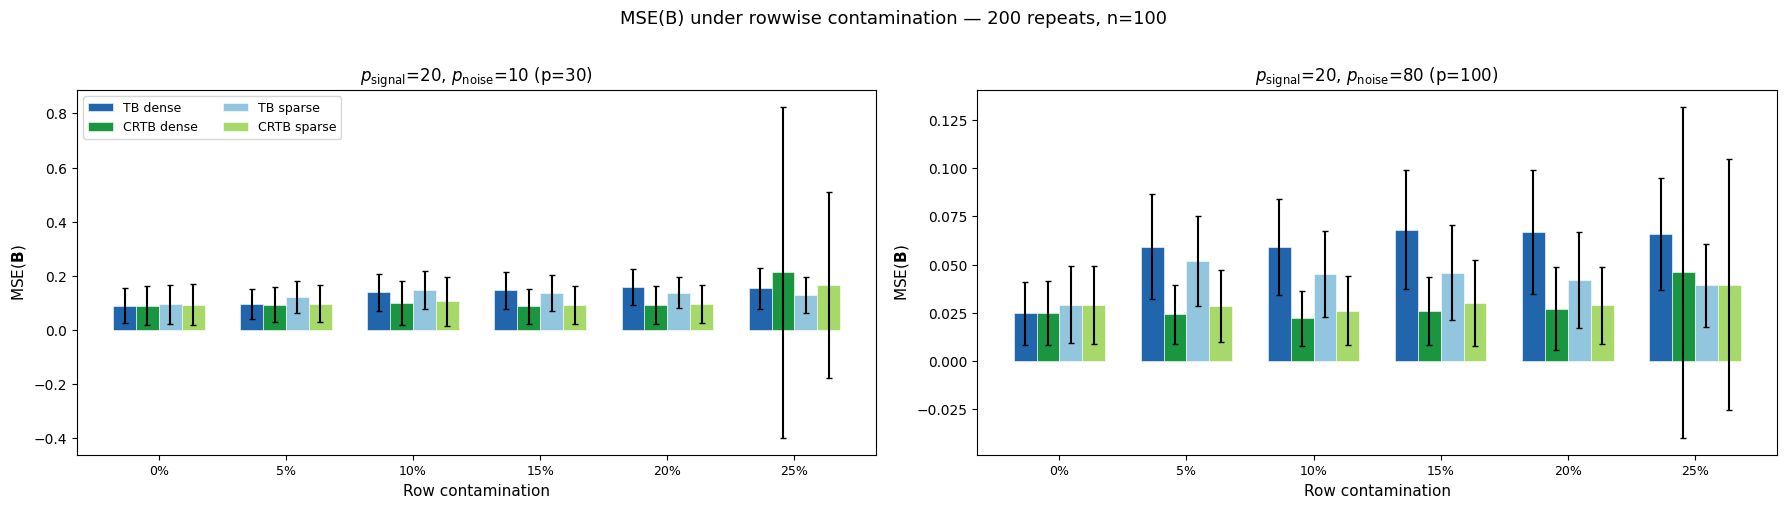

In [12]:
cont_labels_rw = [f"{int(c*100)}%" for c in row_cont_pcts]

n_configs = len(dim_configs)
fig, axes = plt.subplots(1, n_configs, figsize=(9 * n_configs, 5), sharey=False)
if n_configs == 1:
    axes = [axes]
else:
    axes = list(axes)

for ax_idx, (dim_label, (p_signal, p_noise)) in enumerate(dim_configs.items()):
    ax = axes[ax_idx]
    sub = df_rw[df_rw['dim_config'] == dim_label].copy()

    x = np.arange(len(row_cont_pcts))
    n_methods = len(all_methods)
    width = 0.18

    for i, (label, col) in enumerate(all_methods):
        offset = (i - (n_methods - 1) / 2) * width
        vals = sub[f'{col}_mean'].values
        errs = sub[f'{col}_sd'].values
        ax.bar(x + offset, vals, width, yerr=errs, label=label,
               color=colors_4[label], edgecolor='white', linewidth=0.4, capsize=2)

    ax.set_xticks(x)
    ax.set_xticklabels(cont_labels_rw)
    ax.set_xlabel('Row contamination')
    ax.set_ylabel('MSE($\\mathbf{B}$)')
    ax.set_title(f'$p_{{\\rm signal}}$={p_signal}, $p_{{\\rm noise}}$={p_noise} (p={p_signal+p_noise})')
    if ax_idx == 0:
        ax.legend(loc='upper left', ncol=2)

fig.suptitle(f'MSE(B) under rowwise contamination — {n_repeats} repeats, n={n}', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('simulation_crtb_rowwise_bars.png', dpi=150, bbox_inches='tight')
plt.show()

## MSE vs cell contamination percentage (sweep)

Fixed configuration: p_signal=20, p_noise=80 (p=100).  
Cell contamination swept from 0 % to 35 %.

In [13]:
rng_sweep = np.random.default_rng(123)
cont_sweep = np.arange(0, 0.36, 0.05)
p_signal_sw, p_noise_sw = 20, 80
n_rep_sw = 50

sweep_methods = ['tb_mse', 'crtb_mse', 'tbs_mse', 'crtbs_mse']
sweep_results = {m: {'mean': [], 'sd': []} for m in sweep_methods}

t0 = time.time()
for ccp in cont_sweep:
    collected = {m: [] for m in sweep_methods}
    for rep in range(n_rep_sw):
        res = run_single_cellwise(rng_sweep, n, p_signal_sw, p_noise_sw, k, q,
                         sigma_e, sigma_f, ccp, outlier_shift, row_rate)
        for m in sweep_methods:
            collected[m].append(res.get(m, np.nan))
    for m in sweep_methods:
        sweep_results[m]['mean'].append(np.nanmean(collected[m]))
        sweep_results[m]['sd'].append(np.nanstd(collected[m]))
    print(f"  cont={ccp*100:.0f}%  "
          f"TB={sweep_results['tb_mse']['mean'][-1]:.4f}  "
          f"CRTB={sweep_results['crtb_mse']['mean'][-1]:.4f}  "
          f"({time.time()-t0:.0f}s)", flush=True)

print(f"Done in {time.time()-t0:.0f}s")

  cont=0%  TB=0.0277  CRTB=0.0282  (81s)
  cont=5%  TB=0.1637  CRTB=0.0283  (188s)
  cont=10%  TB=0.1652  CRTB=0.0321  (302s)
  cont=15%  TB=0.1688  CRTB=0.0394  (408s)
  cont=20%  TB=0.1698  CRTB=0.0557  (517s)
  cont=25%  TB=0.1881  CRTB=0.0812  (620s)
  cont=30%  TB=0.2129  CRTB=0.1226  (729s)
  cont=35%  TB=0.2238  CRTB=0.1830  (832s)
Done in 832s


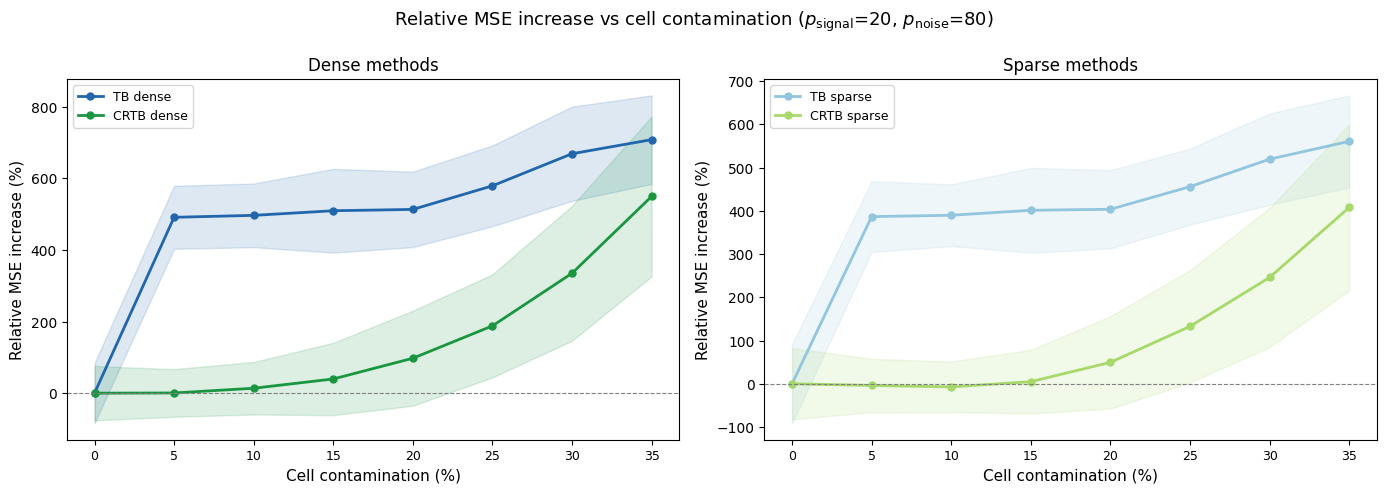

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sweep_labels = {
    'tb_mse':    ('TB dense',    colors_4['TB dense']),
    'crtb_mse':  ('CRTB dense',  colors_4['CRTB dense']),
    'tbs_mse':   ('TB sparse',   colors_4['TB sparse']),
    'crtbs_mse': ('CRTB sparse', colors_4['CRTB sparse']),
}
baselines = {m: sweep_results[m]['mean'][0] for m in sweep_methods}

for ax, method_subset, title in [
    (axes[0], ['tb_mse', 'crtb_mse'],   'Dense methods'),
    (axes[1], ['tbs_mse', 'crtbs_mse'], 'Sparse methods'),
]:
    for m in method_subset:
        label, color = sweep_labels[m]
        means = np.array(sweep_results[m]['mean'])
        sds   = np.array(sweep_results[m]['sd'])
        rel   = (means - baselines[m]) / max(baselines[m], 1e-10) * 100
        rel_sd = sds / max(baselines[m], 1e-10) * 100
        ax.plot(cont_sweep * 100, rel, 'o-', label=label, color=color, linewidth=2, markersize=5)
        ax.fill_between(cont_sweep * 100, rel - rel_sd, rel + rel_sd, alpha=0.15, color=color)
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Cell contamination (%)')
    ax.set_ylabel('Relative MSE increase (%)')
    ax.set_title(title)
    ax.legend()

fig.suptitle(f'Relative MSE increase vs cell contamination '
             f'($p_{{\\rm signal}}$={p_signal_sw}, $p_{{\\rm noise}}$={p_noise_sw})',
             fontsize=13)
plt.tight_layout()
plt.savefig('simulation_crtb_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## Variable selection F1 score

Sparse methods only, on configurations that include uninformative variables.

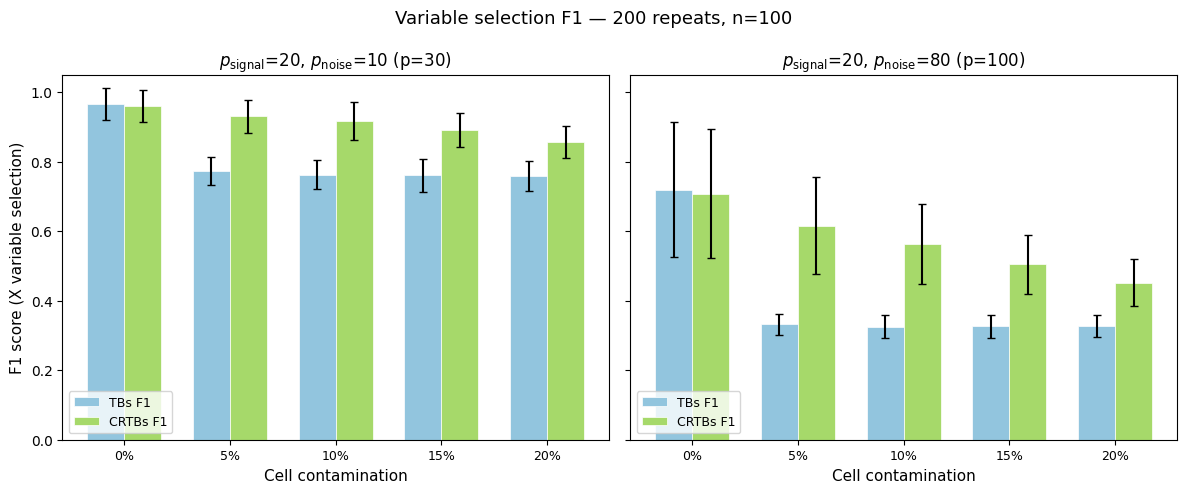

In [15]:
noise_configs = {k_: v for k_, v in dim_configs.items() if v[1] > 0}
n_panels = len(noise_configs)

fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5), sharey=True)
if n_panels == 1:
    axes = [axes]

f1_methods = [
    ('TBs F1',   'tbs_f1',   colors_4['TB sparse']),
    ('CRTBs F1', 'crtbs_f1', colors_4['CRTB sparse']),
]
x = np.arange(len(cell_cont_pcts))
width = 0.35

for ax_idx, (dim_label, (ps_, pn)) in enumerate(noise_configs.items()):
    ax = axes[ax_idx]
    sub = df_cw[df_cw['dim_config'] == dim_label]

    for i, (label, col, color) in enumerate(f1_methods):
        offset = (i - 0.5) * width
        ax.bar(x + offset, sub[f'{col}_mean'].values, width,
               yerr=sub[f'{col}_sd'].values, label=label,
               color=color, edgecolor='white', linewidth=0.5, capsize=3)

    ax.set_xticks(x)
    ax.set_xticklabels(cont_labels)
    ax.set_xlabel('Cell contamination')
    ax.set_ylim(0, 1.05)
    ax.set_title(f'$p_{{\\rm signal}}$={ps_}, $p_{{\\rm noise}}$={pn} (p={ps_+pn})')
    if ax_idx == 0:
        ax.set_ylabel('F1 score (X variable selection)')
    ax.legend(loc='lower left')

fig.suptitle(f'Variable selection F1 — {n_repeats} repeats, n={n}', fontsize=13)
plt.tight_layout()
plt.savefig('simulation_crtb_f1.png', dpi=150, bbox_inches='tight')
plt.show()

## Cellwise outlier detection quality (CRTB)

Precision, recall, and F1 for CRTB's column-wise prefilter detection
of the true contaminated cells in X and Y, averaged over repeats.

In [16]:
# Cell detection summary table
det_cols_x = ['dim_config', 'cell_cont_pct',
              'cell_prec_x_mean', 'cell_rec_x_mean', 'cell_f1_x_mean',
              'cell_tp_x_mean', 'cell_fp_x_mean', 'cell_fn_x_mean']
det_cols_y = ['dim_config', 'cell_cont_pct',
              'cell_prec_y_mean', 'cell_rec_y_mean', 'cell_f1_y_mean',
              'cell_tp_y_mean', 'cell_fp_y_mean', 'cell_fn_y_mean']

det_x = df_cw[df_cw['cell_cont_pct'] > 0][det_cols_x].copy()
det_x['cell_cont_pct'] = (det_x['cell_cont_pct'] * 100).astype(int).astype(str) + '%'
det_x.columns = ['Config', 'Cell %', 'Prec', 'Recall', 'F1', 'TP', 'FP', 'FN']
for c in ['Prec', 'Recall', 'F1']:
    det_x[c] = det_x[c].round(3)
for c in ['TP', 'FP', 'FN']:
    det_x[c] = det_x[c].round(1)
print("=== CRTB cellwise outlier detection — X block ===")
display(det_x)

det_y = df_cw[df_cw['cell_cont_pct'] > 0][det_cols_y].copy()
det_y['cell_cont_pct'] = (det_y['cell_cont_pct'] * 100).astype(int).astype(str) + '%'
det_y.columns = ['Config', 'Cell %', 'Prec', 'Recall', 'F1', 'TP', 'FP', 'FN']
for c in ['Prec', 'Recall', 'F1']:
    det_y[c] = det_y[c].round(3)
for c in ['TP', 'FP', 'FN']:
    det_y[c] = det_y[c].round(1)
print("\n=== CRTB cellwise outlier detection — Y block ===")
display(det_y)


=== CRTB cellwise outlier detection — X block ===


,Config,Cell %,Prec,Recall,F1,TP,FP,FN
1,p20_noise10,5%,0.799,1.0,0.887,116.8,29.9,0.0
2,p20_noise10,10%,0.899,1.0,0.946,204.7,23.2,0.0
3,p20_noise10,15%,0.942,1.0,0.970,301.3,18.6,0.0
4,p20_noise10,20%,0.962,1.0,0.980,398.8,15.9,0.0
6,p20_noise80,5%,0.490,1.0,0.656,117.3,123.1,0.0
7,p20_noise80,10%,0.638,1.0,0.779,204.4,116.3,0.0
8,p20_noise80,15%,0.729,1.0,0.843,301.3,112.1,0.0
9,p20_noise80,20%,0.786,1.0,0.880,399.8,109.2,0.0



=== CRTB cellwise outlier detection — Y block ===


,Config,Cell %,Prec,Recall,F1,TP,FP,FN
1,p20_noise10,5%,0.988,0.875,0.924,63.5,0.7,9.1
2,p20_noise10,10%,0.992,0.877,0.925,69.6,0.6,9.9
3,p20_noise10,15%,0.996,0.833,0.899,74.7,0.3,15.2
4,p20_noise10,20%,0.998,0.767,0.858,78.0,0.1,23.9
6,p20_noise80,5%,0.989,0.881,0.927,63.7,0.7,8.7
7,p20_noise80,10%,0.992,0.852,0.911,68.1,0.5,11.8
8,p20_noise80,15%,0.995,0.832,0.899,74.0,0.3,15.0
9,p20_noise80,20%,0.999,0.751,0.845,76.3,0.1,25.6


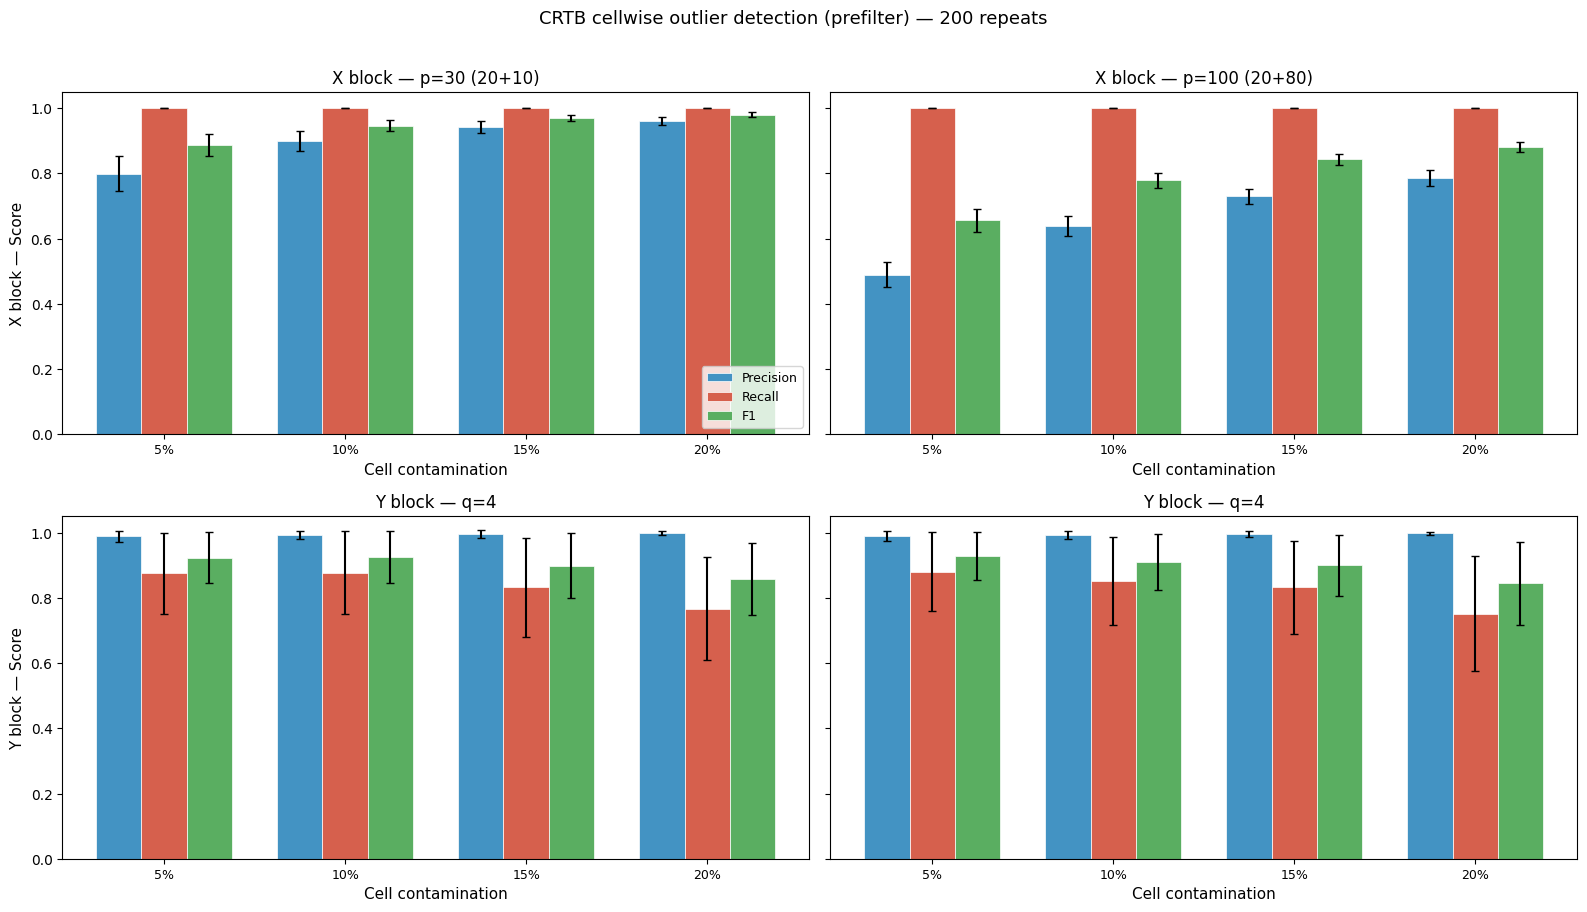

In [17]:
# Precision / Recall / F1 bar chart for X and Y block cell detection
det_metrics = [('Precision', 'cell_prec'), ('Recall', 'cell_rec'), ('F1', 'cell_f1')]
det_colors  = ['#4393c3', '#d6604d', '#5aae61']

cont_nz = [c for c in cell_cont_pcts if c > 0]
cont_labels_nz = [f"{int(c*100)}%" for c in cont_nz]

n_configs = len(dim_configs)
fig, axes = plt.subplots(2, n_configs, figsize=(8 * n_configs, 9), sharey=True)

for row_idx, (block, suffix) in enumerate([('X', '_x'), ('Y', '_y')]):
    for ax_idx, (dim_label, (p_signal, p_noise)) in enumerate(dim_configs.items()):
        ax = axes[row_idx, ax_idx]
        sub = df_cw[(df_cw['dim_config'] == dim_label) & (df_cw['cell_cont_pct'] > 0)]
        x = np.arange(len(cont_nz))
        width = 0.25

        for i, (label, col_base) in enumerate(det_metrics):
            col = col_base + suffix
            offset = (i - 1) * width
            vals = sub[f'{col}_mean'].values
            errs = sub[f'{col}_sd'].values
            ax.bar(x + offset, vals, width, yerr=errs, label=label,
                   color=det_colors[i], edgecolor='white', linewidth=0.5, capsize=3)

        ax.set_xticks(x)
        ax.set_xticklabels(cont_labels_nz)
        ax.set_xlabel('Cell contamination')
        ax.set_ylim(0, 1.05)
        p_total = p_signal + p_noise
        if block == 'X':
            ax.set_title(f'{block} block — p={p_total} ({p_signal}+{p_noise})')
        else:
            ax.set_title(f'{block} block — q={q}')
        if ax_idx == 0:
            ax.set_ylabel(f'{block} block — Score')
        if row_idx == 0 and ax_idx == 0:
            ax.legend(loc='lower right')

fig.suptitle(f'CRTB cellwise outlier detection (prefilter) — {n_repeats} repeats',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('simulation_crtb_cell_detection.png', dpi=150, bbox_inches='tight')
plt.show()


## Publication-grade figures

Re-render the key plots with larger fonts and save as individual PDFs
in `../paper/figures/`.

In [18]:
import matplotlib
import matplotlib.pyplot as plt
import os

fig_dir = os.path.join('..', 'paper', 'figures')
os.makedirs(fig_dir, exist_ok=True)

# Publication rcParams
pub_rc = {
    'font.family': 'serif',
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'text.usetex': False,
    'mathtext.fontset': 'cm',
}
matplotlib.rcParams.update(pub_rc)
print('Publication rcParams set.')


Publication rcParams set.


Saved ../paper/figures/sim_mse_cellwise_p20_noise10.pdf


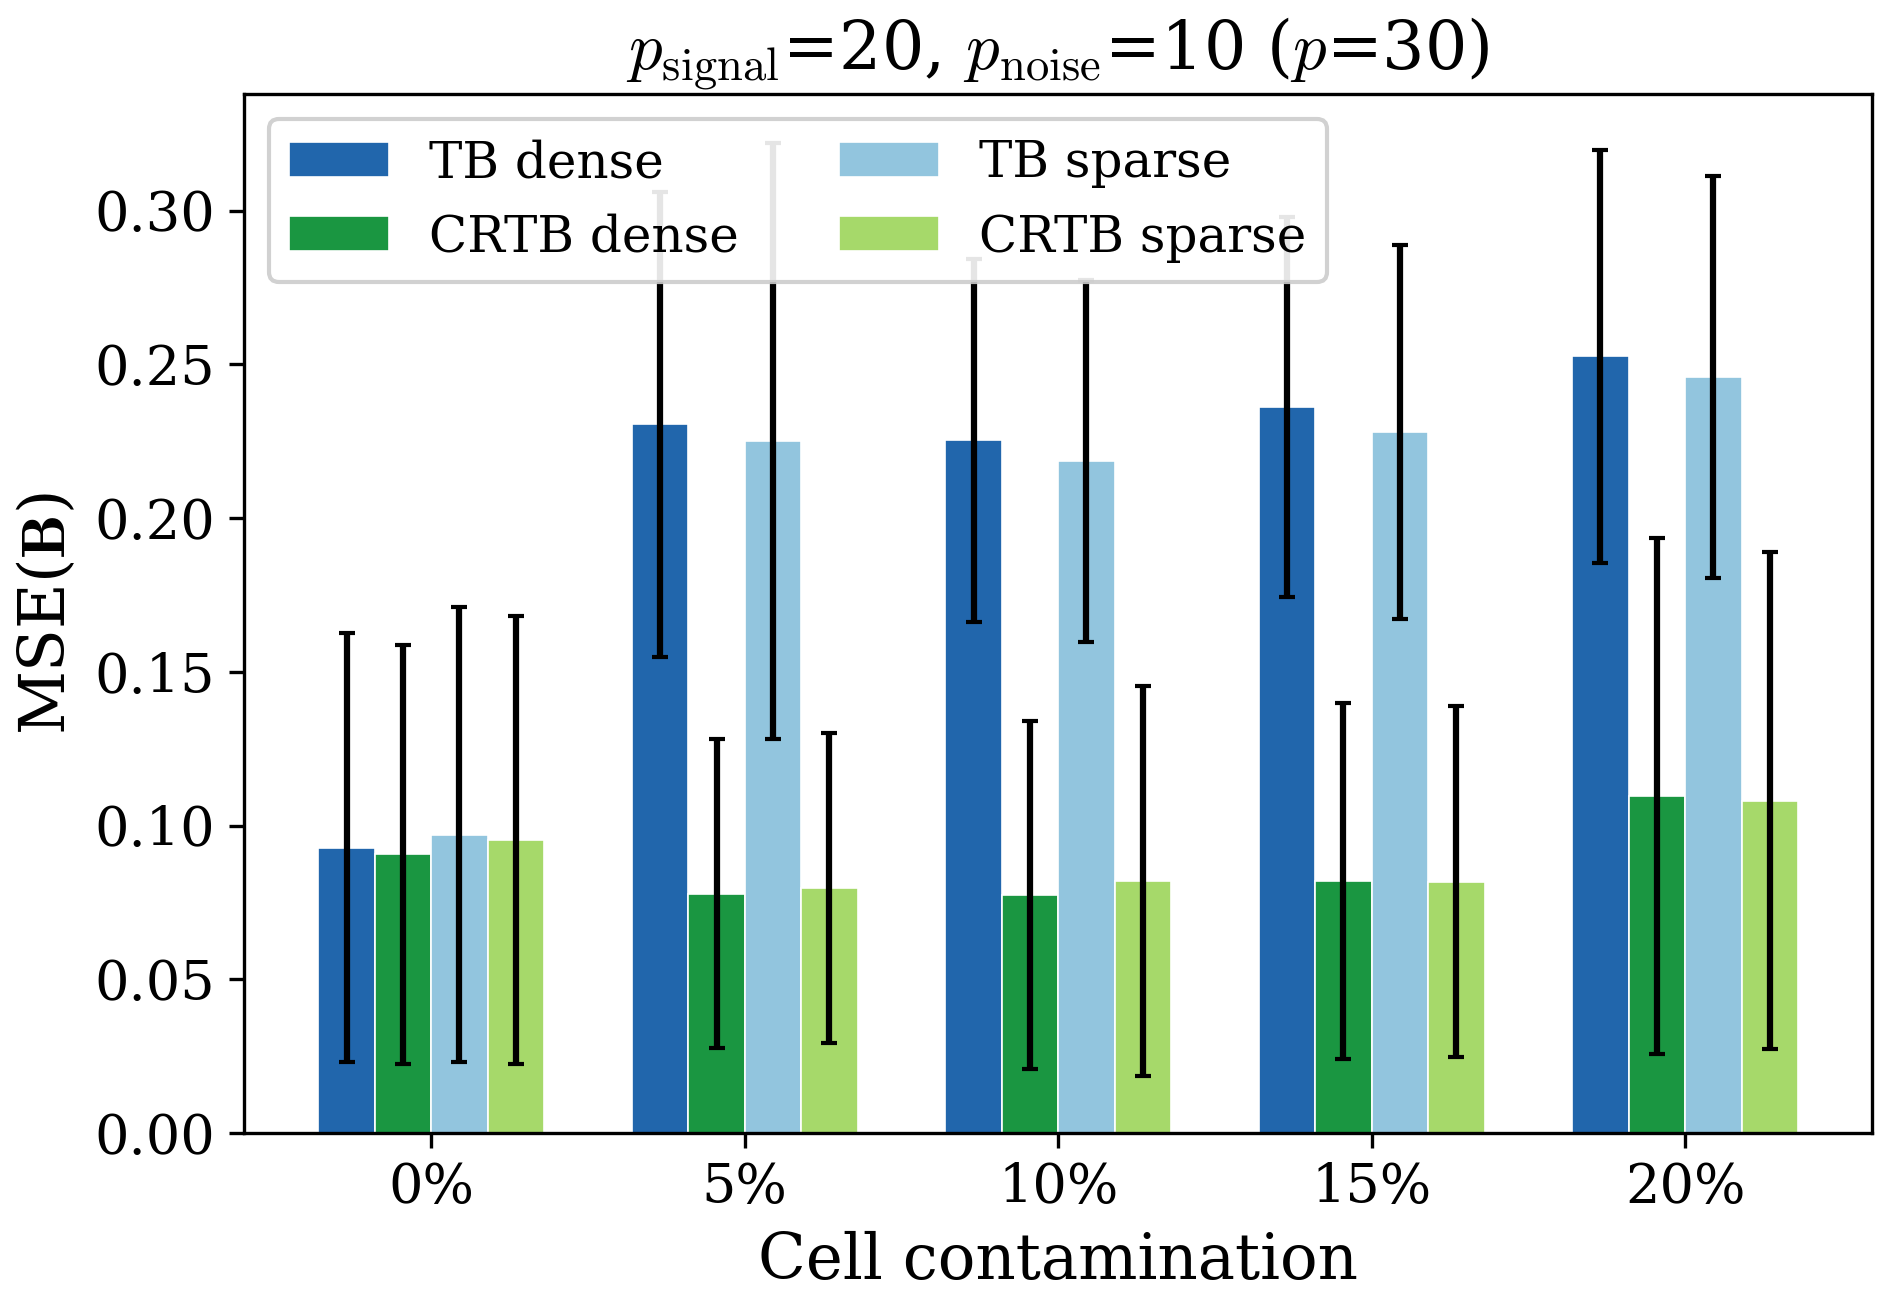

Saved ../paper/figures/sim_mse_cellwise_p20_noise80.pdf


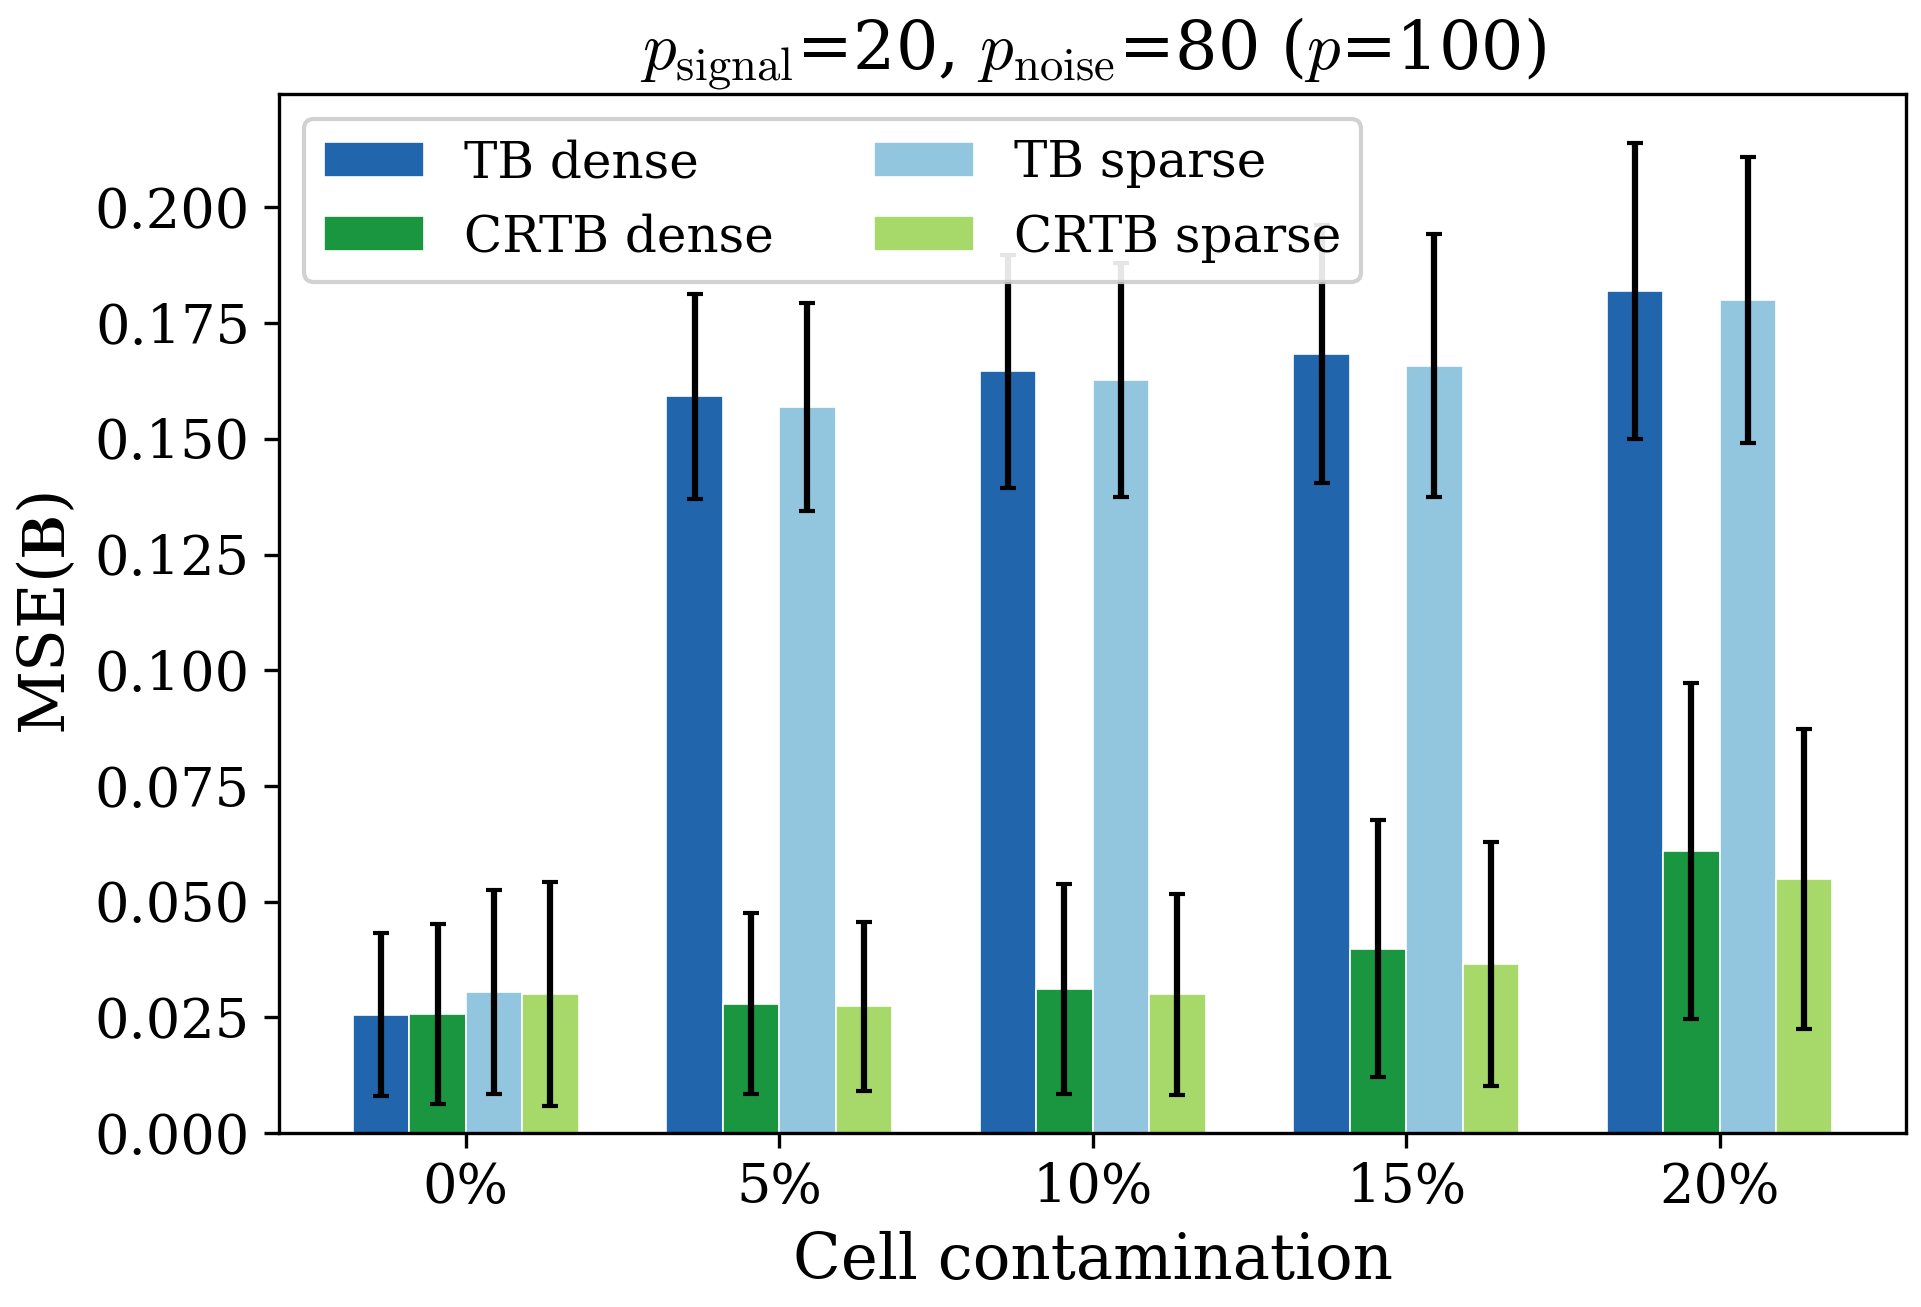

In [19]:
# --- Publication Figure: Cellwise MSE bar charts ---
cont_labels = [f"{int(c*100)}%" for c in cell_cont_pcts]

for dim_label, (p_signal, p_noise) in dim_configs.items():
    fig, ax = plt.subplots(figsize=(7, 4.5))
    sub = df_cw[df_cw['dim_config'] == dim_label].copy()

    x = np.arange(len(cell_cont_pcts))
    n_methods = len(all_methods)
    width = 0.18

    for i, (label, col) in enumerate(all_methods):
        offset = (i - (n_methods - 1) / 2) * width
        vals = sub[f'{col}_mean'].values
        errs = sub[f'{col}_sd'].values
        ax.bar(x + offset, vals, width, yerr=errs, label=label,
               color=colors_4[label], edgecolor='white', linewidth=0.4, capsize=2)

    ax.set_xticks(x)
    ax.set_xticklabels(cont_labels)
    ax.set_xlabel('Cell contamination')
    ax.set_ylabel(r'MSE($\mathbf{B}$)')
    p_total = p_signal + p_noise
    ax.set_title(f'$p_{{\\rm signal}}$={p_signal}, '
                 f'$p_{{\\rm noise}}$={p_noise} ($p$={p_total})')
    ax.legend(loc='upper left', ncol=2, framealpha=0.9)

    fname = os.path.join(fig_dir, f'sim_mse_cellwise_{dim_label}.pdf')
    fig.savefig(fname)
    print(f'Saved {fname}')
    plt.show()


Saved ../paper/figures/sim_f1_p20_noise10.pdf


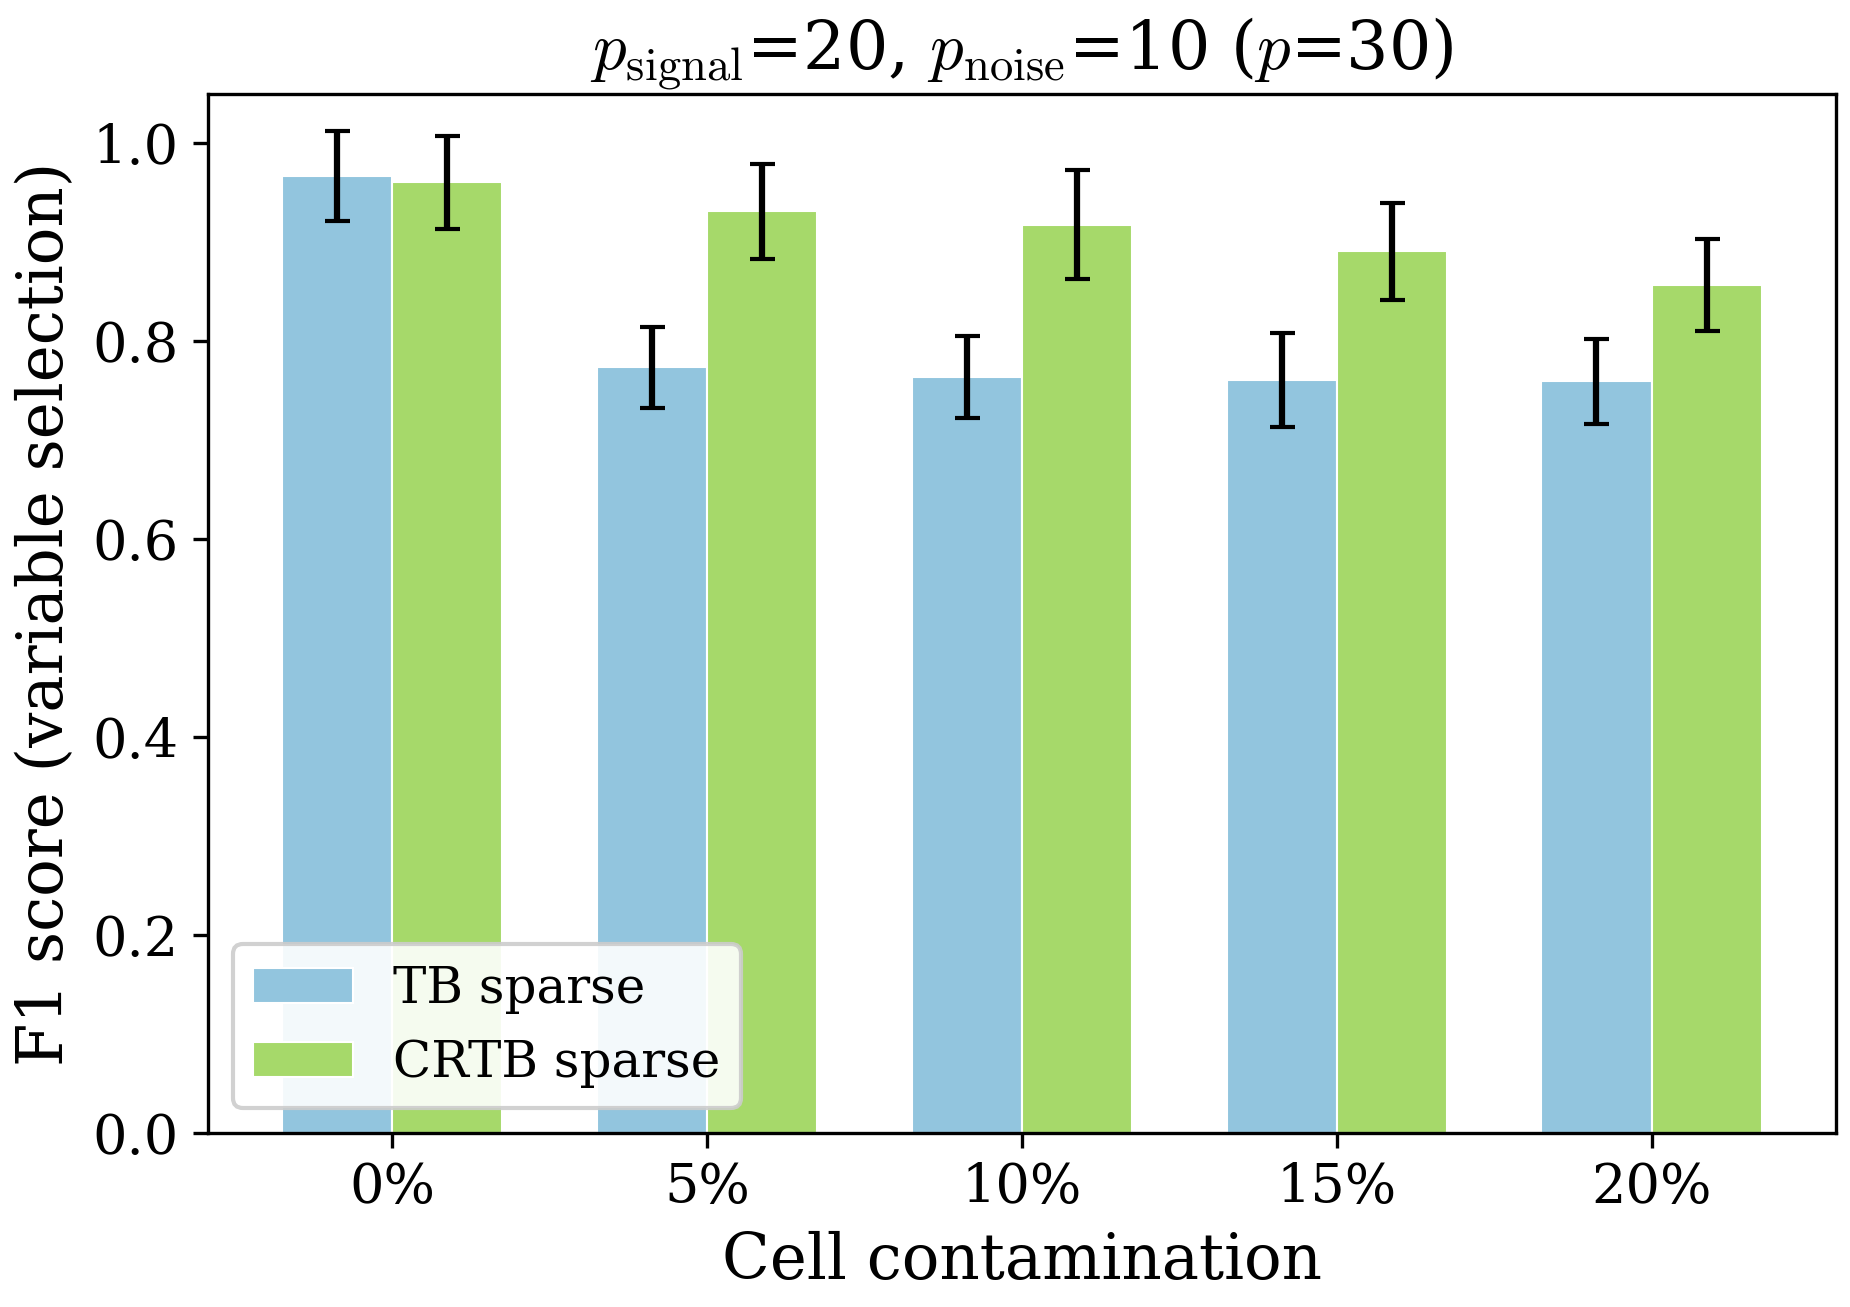

Saved ../paper/figures/sim_f1_p20_noise80.pdf


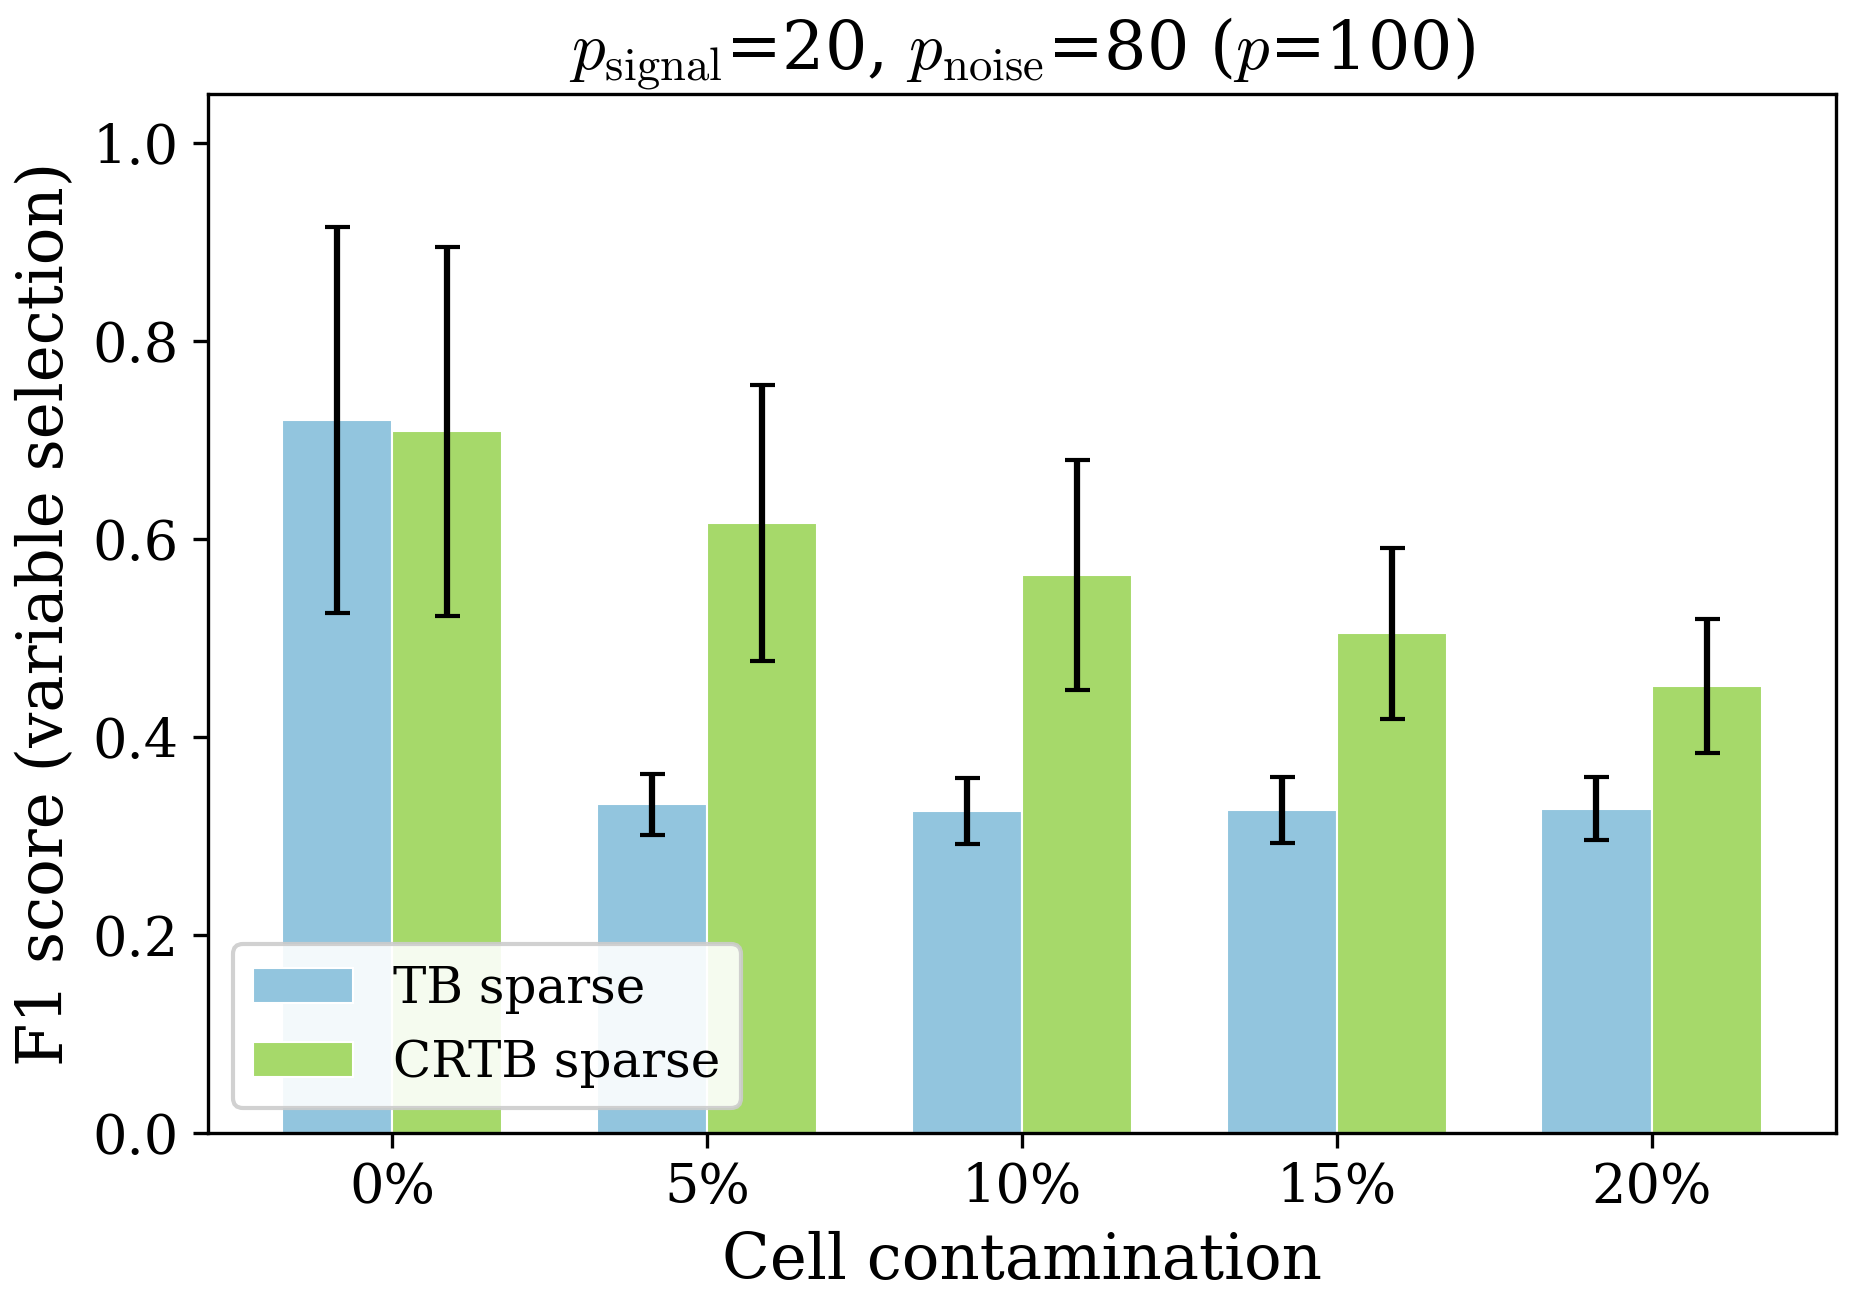

In [20]:
# --- Publication Figure: Variable selection F1 ---
noise_configs = {k_: v for k_, v in dim_configs.items() if v[1] > 0}

f1_methods = [
    ('TB sparse',   'tbs_f1',   colors_4['TB sparse']),
    ('CRTB sparse', 'crtbs_f1', colors_4['CRTB sparse']),
]
x = np.arange(len(cell_cont_pcts))
width = 0.35

for dim_label, (ps_, pn) in noise_configs.items():
    fig, ax = plt.subplots(figsize=(7, 4.5))
    sub = df_cw[df_cw['dim_config'] == dim_label]

    for i, (label, col, color) in enumerate(f1_methods):
        offset = (i - 0.5) * width
        ax.bar(x + offset, sub[f'{col}_mean'].values, width,
               yerr=sub[f'{col}_sd'].values, label=label,
               color=color, edgecolor='white', linewidth=0.5, capsize=3)

    ax.set_xticks(x)
    ax.set_xticklabels(cont_labels)
    ax.set_xlabel('Cell contamination')
    ax.set_ylabel('F1 score (variable selection)')
    ax.set_ylim(0, 1.05)
    p_total = ps_ + pn
    ax.set_title(f'$p_{{\\rm signal}}$={ps_}, $p_{{\\rm noise}}$={pn} ($p$={p_total})')
    ax.legend(loc='lower left', framealpha=0.9)

    fname = os.path.join(fig_dir, f'sim_f1_{dim_label}.pdf')
    fig.savefig(fname)
    print(f'Saved {fname}')
    plt.show()


Saved ../paper/figures/sim_cell_detection_p20_noise10.pdf


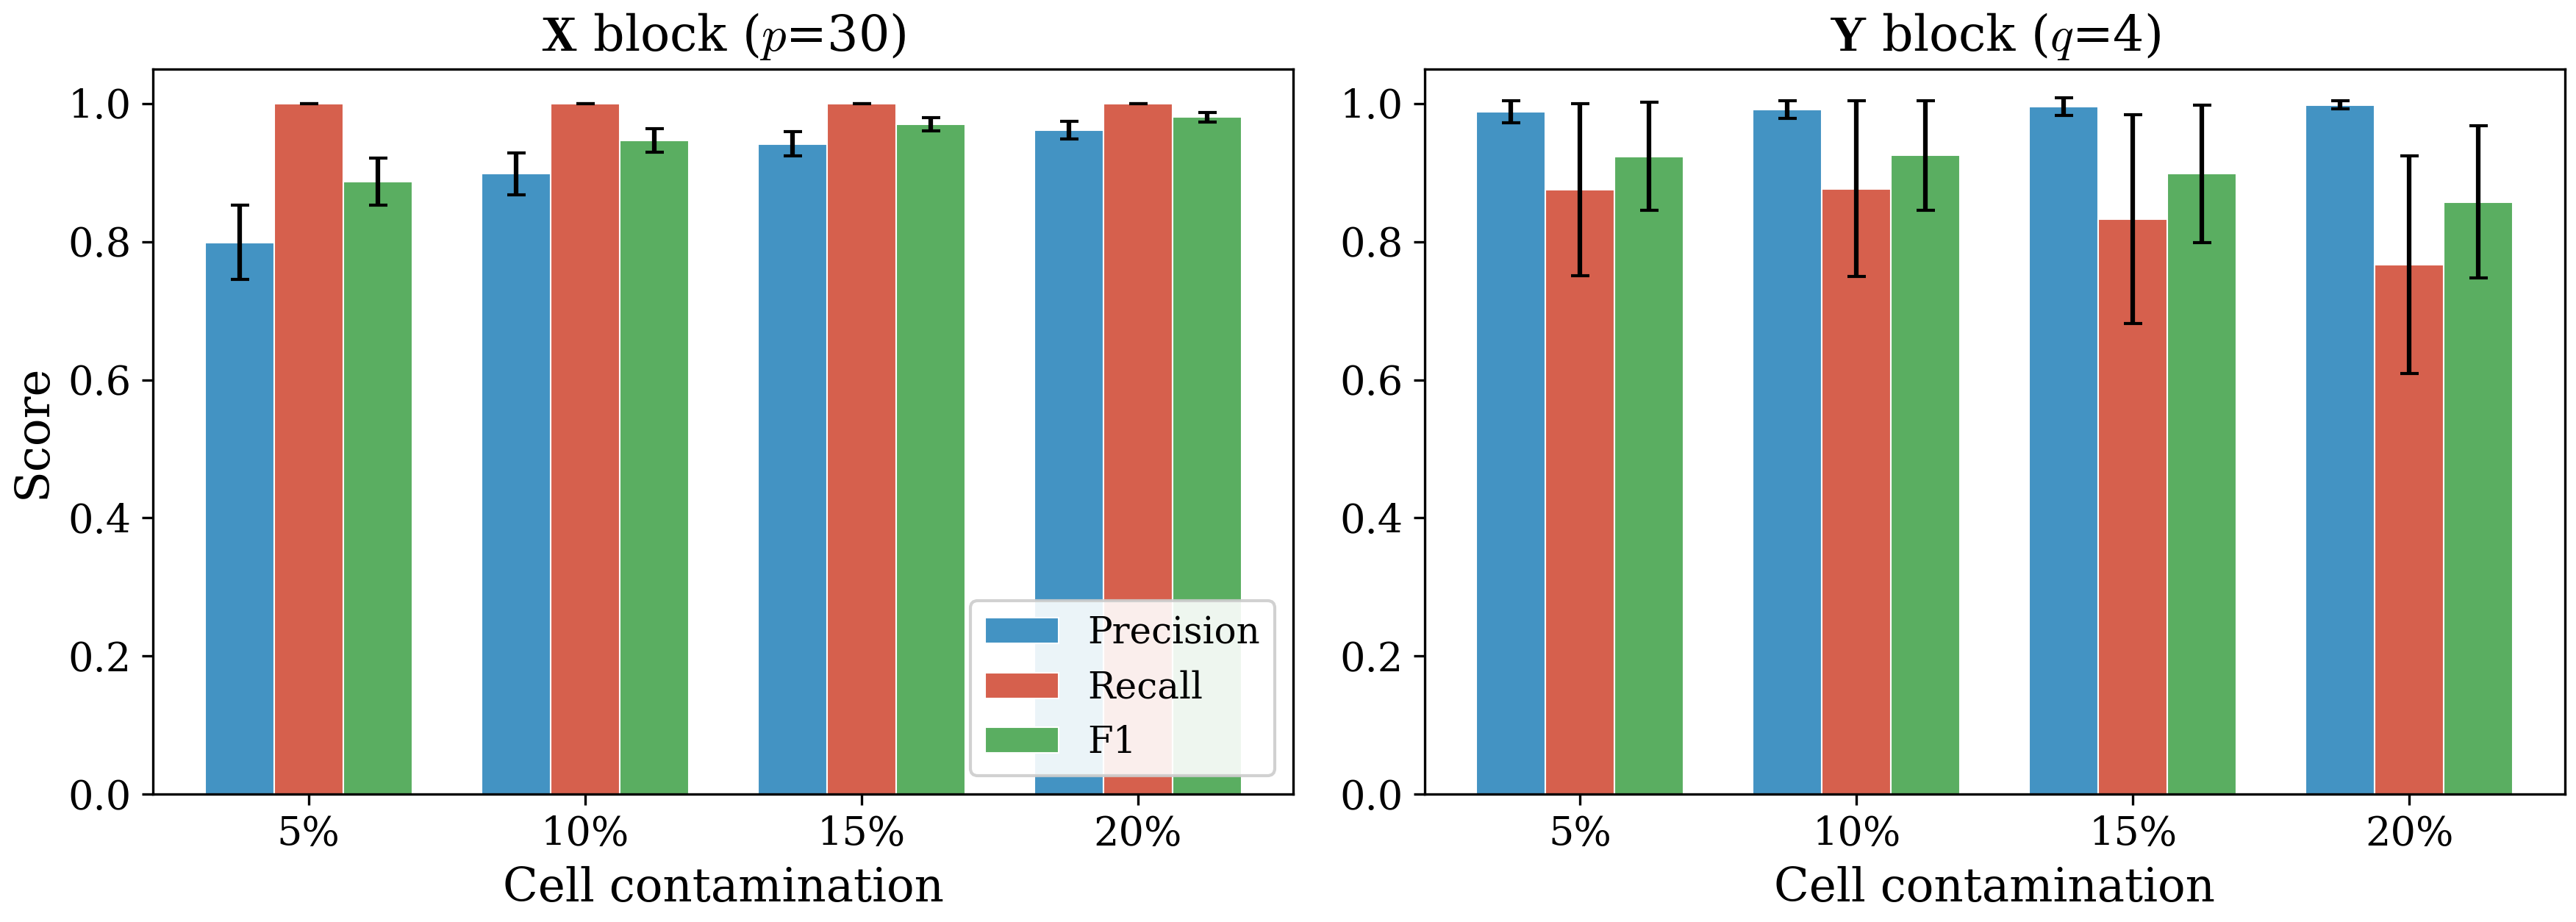

Saved ../paper/figures/sim_cell_detection_p20_noise80.pdf


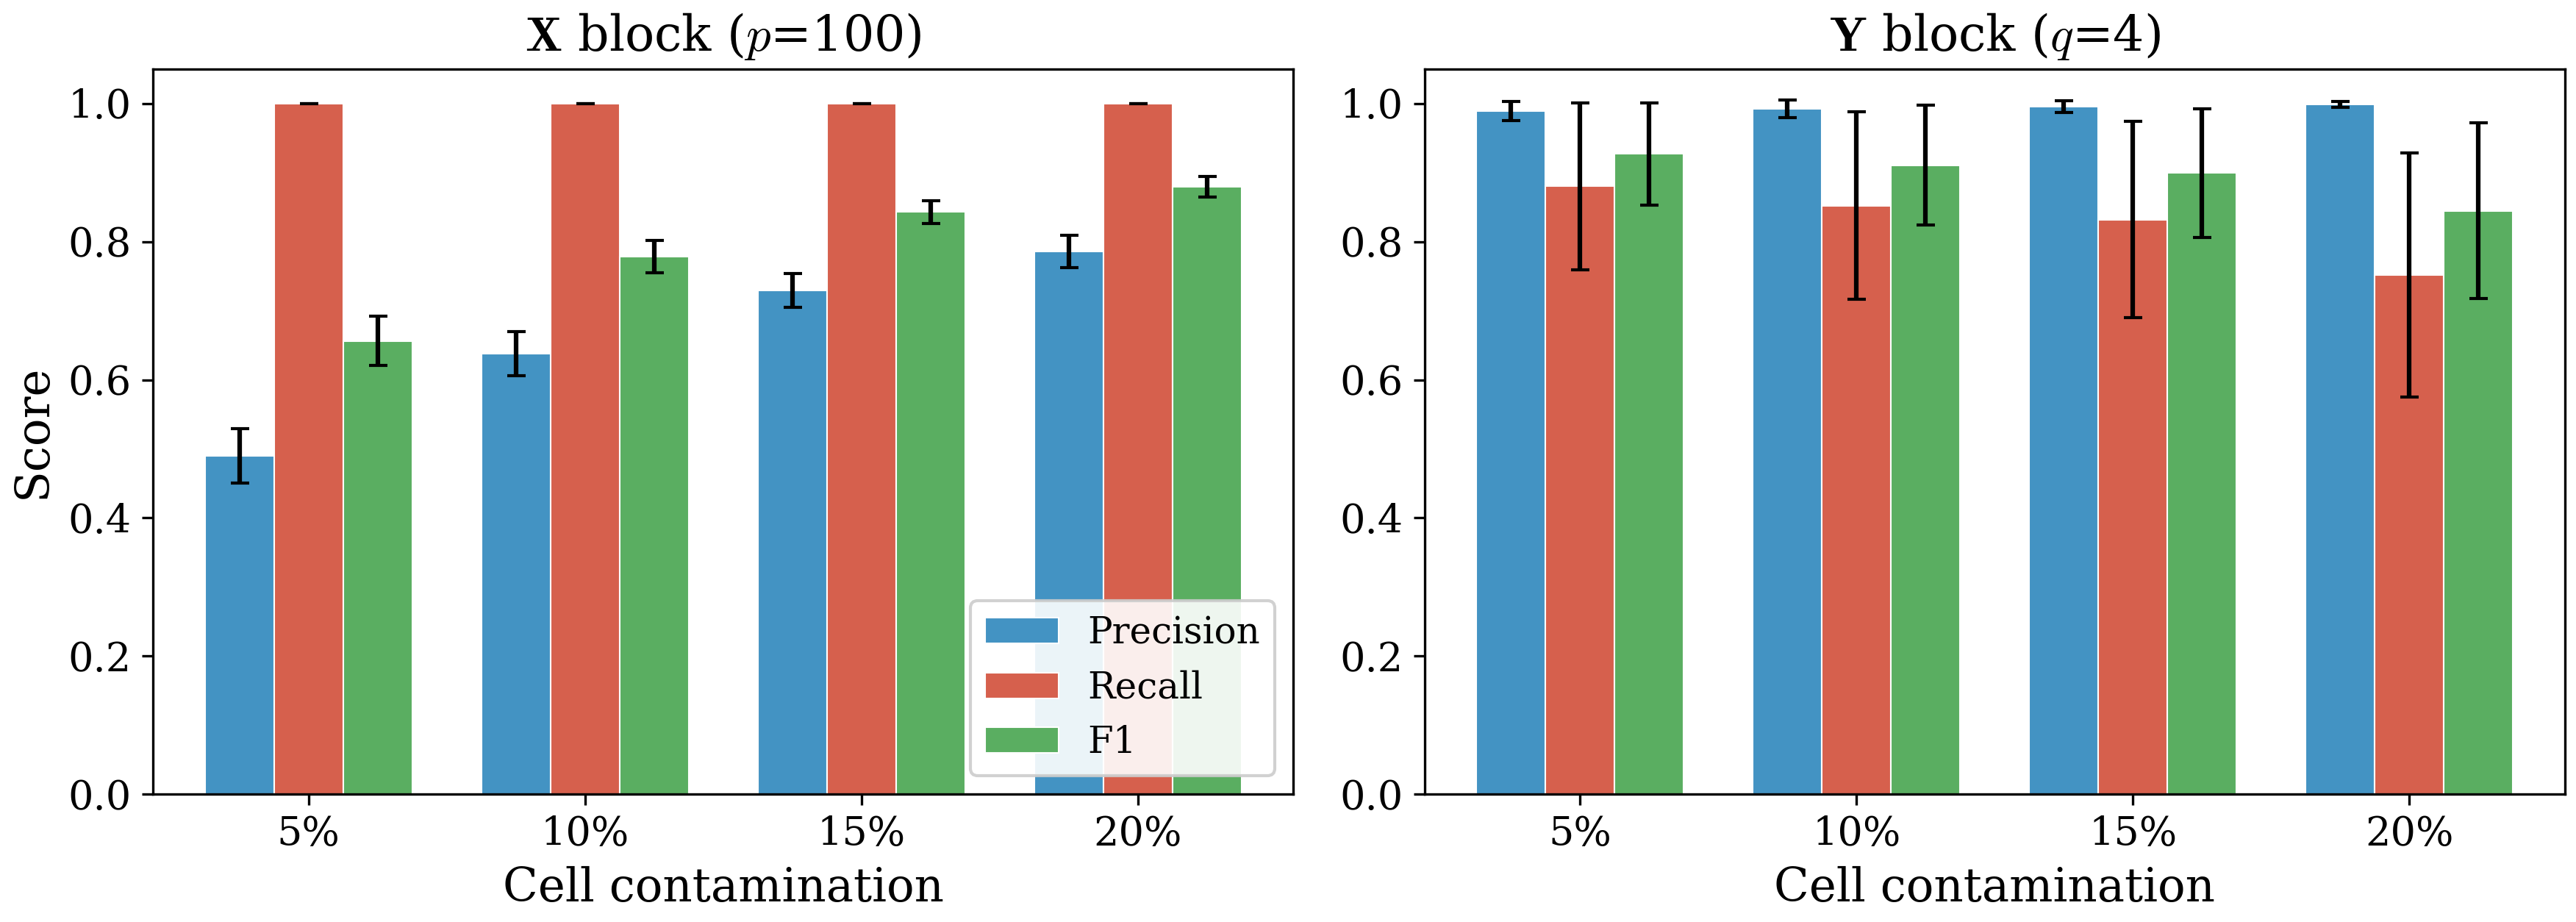

In [21]:
# --- Publication Figure: Cellwise detection quality ---
det_metrics = [('Precision', 'cell_prec'), ('Recall', 'cell_rec'), ('F1', 'cell_f1')]
det_colors  = ['#4393c3', '#d6604d', '#5aae61']

cont_nz = [c for c in cell_cont_pcts if c > 0]
cont_labels_nz = [f"{int(c*100)}%" for c in cont_nz]

for dim_label, (p_signal, p_noise) in dim_configs.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    for col_idx, (block, suffix) in enumerate([('X', '_x'), ('Y', '_y')]):
        ax = axes[col_idx]
        sub = df_cw[(df_cw['dim_config'] == dim_label) & (df_cw['cell_cont_pct'] > 0)]
        x = np.arange(len(cont_nz))
        width = 0.25

        for i, (label, col_base) in enumerate(det_metrics):
            col = col_base + suffix
            offset = (i - 1) * width
            vals = sub[f'{col}_mean'].values
            errs = sub[f'{col}_sd'].values
            ax.bar(x + offset, vals, width, yerr=errs, label=label,
                   color=det_colors[i], edgecolor='white', linewidth=0.5, capsize=3)

        ax.set_xticks(x)
        ax.set_xticklabels(cont_labels_nz)
        ax.set_xlabel('Cell contamination')
        ax.set_ylim(0, 1.05)
        p_total = p_signal + p_noise
        if block == 'X':
            ax.set_title(f'$\\mathbf{{X}}$ block ($p$={p_total})')
            ax.set_ylabel('Score')
        else:
            ax.set_title(f'$\\mathbf{{Y}}$ block ($q$={q})')
        if col_idx == 0:
            ax.legend(loc='lower right', framealpha=0.9)

    plt.tight_layout()
    fname = os.path.join(fig_dir, f'sim_cell_detection_{dim_label}.pdf')
    fig.savefig(fname)
    print(f'Saved {fname}')
    plt.show()


Saved ../paper/figures/sim_mse_sweep.pdf


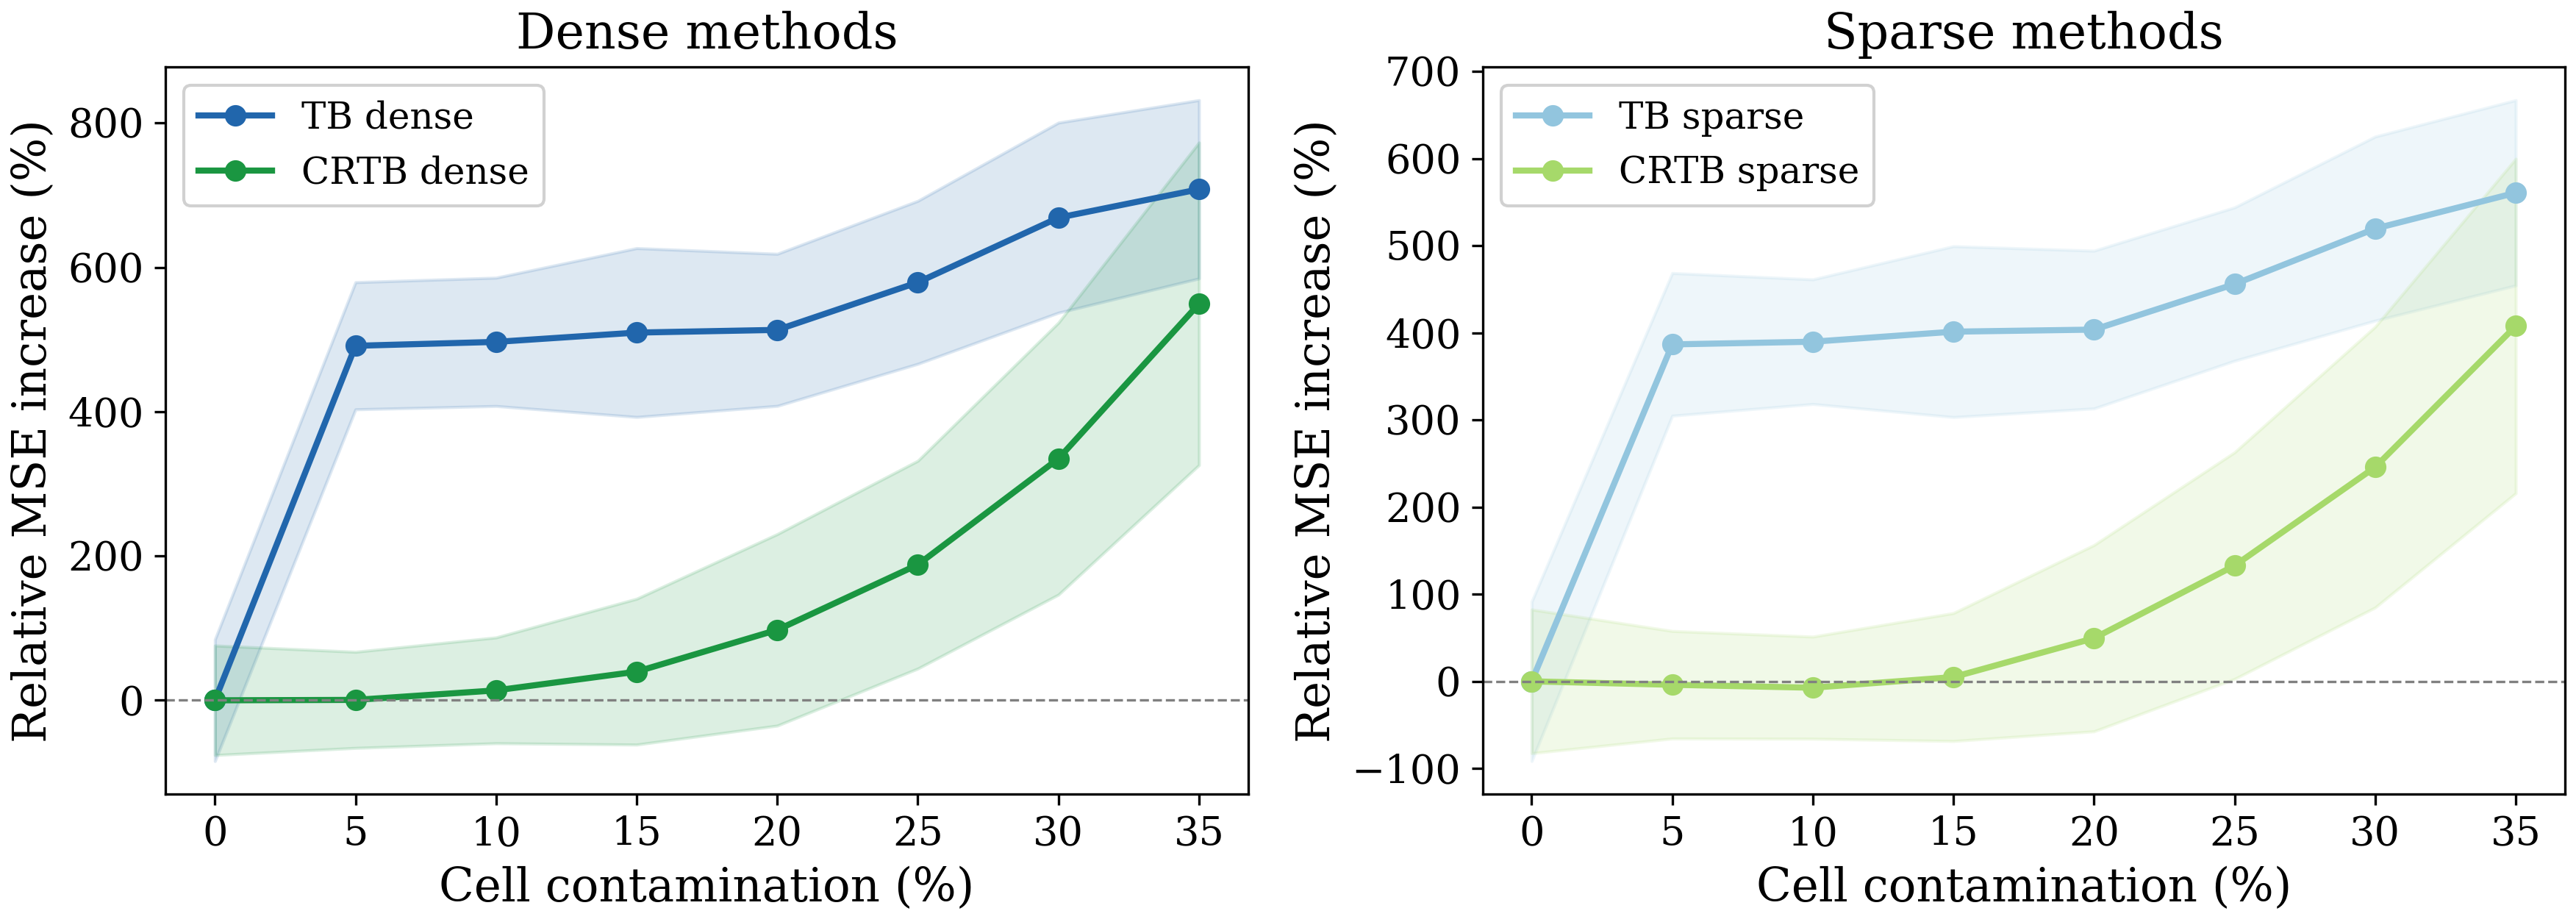

In [22]:
# --- Publication Figure: MSE degradation sweep ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sweep_labels = {
    'tb_mse':    ('TB dense',    colors_4['TB dense']),
    'crtb_mse':  ('CRTB dense',  colors_4['CRTB dense']),
    'tbs_mse':   ('TB sparse',   colors_4['TB sparse']),
    'crtbs_mse': ('CRTB sparse', colors_4['CRTB sparse']),
}
baselines = {m: sweep_results[m]['mean'][0] for m in sweep_methods}

for ax, method_subset, title in [
    (axes[0], ['tb_mse', 'crtb_mse'],   'Dense methods'),
    (axes[1], ['tbs_mse', 'crtbs_mse'], 'Sparse methods'),
]:
    for m in method_subset:
        label, color = sweep_labels[m]
        means = np.array(sweep_results[m]['mean'])
        sds   = np.array(sweep_results[m]['sd'])
        rel   = (means - baselines[m]) / max(baselines[m], 1e-10) * 100
        rel_sd = sds / max(baselines[m], 1e-10) * 100
        ax.plot(cont_sweep * 100, rel, 'o-', label=label, color=color,
                linewidth=2, markersize=6)
        ax.fill_between(cont_sweep * 100, rel - rel_sd, rel + rel_sd,
                        alpha=0.15, color=color)
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Cell contamination (%)')
    ax.set_ylabel('Relative MSE increase (%)')
    ax.set_title(title)
    ax.legend(framealpha=0.9)

plt.tight_layout()
fname = os.path.join(fig_dir, 'sim_mse_sweep.pdf')
fig.savefig(fname)
print(f'Saved {fname}')
plt.show()


## Assertions

Sanity checks asserting that CRTB outperforms TB under contamination,
and that both methods perform comparably at 0 % contamination.

In [23]:
failures = []

# ---- Part 1: Cellwise contamination assertions ----
for dim_label in dim_configs:
    sub = df_cw[df_cw['dim_config'] == dim_label]

    # At 0 % contamination CRTB should not be dramatically worse than TB
    row0 = sub[sub['cell_cont_pct'] == 0.0].iloc[0]
    ratio_clean = row0['crtb_mse_mean'] / max(row0['tb_mse_mean'], 1e-12)
    if ratio_clean > 3.0:
        failures.append(f"CW {dim_label} @ 0%: CRTB/TB ratio = {ratio_clean:.2f} (expected <= 3)")

    # At 5% and 10% cell contamination CRTB should clearly beat TB
    for ccp in [0.05, 0.10]:
        row = sub[sub['cell_cont_pct'] == ccp]
        if len(row) == 0:
            continue
        row = row.iloc[0]
        if row['crtb_mse_mean'] > row['tb_mse_mean'] * 1.1:
            failures.append(
                f"CW {dim_label} @ {int(ccp*100)}%: CRTB > 1.1*TB")

    # TB should break down (cellwise)
    row_clean = sub[sub['cell_cont_pct'] == 0.0].iloc[0]
    row_cont  = sub[sub['cell_cont_pct'] == 0.10].iloc[0]
    tb_ratio = row_cont['tb_mse_mean'] / max(row_clean['tb_mse_mean'], 1e-12)
    if tb_ratio < 1.5:
        failures.append(f"CW {dim_label}: TB not breaking down, ratio={tb_ratio:.2f}")

# ---- Part 2: Rowwise contamination assertions ----
for dim_label in dim_configs:
    sub = df_rw[df_rw['dim_config'] == dim_label]

    # TB should break down under rowwise contamination
    row_clean = sub[sub['row_cont_pct'] == 0.0].iloc[0]
    row_cont  = sub[sub['row_cont_pct'] == 0.10].iloc[0]
    tb_ratio = row_cont['tb_mse_mean'] / max(row_clean['tb_mse_mean'], 1e-12)
    if tb_ratio < 1.3:
        failures.append(f"RW {dim_label}: TB not breaking down, ratio={tb_ratio:.2f}")

    # CRTB should handle rowwise contamination up to 25%
    for rcp in [0.10, 0.20, 0.25]:
        row = sub[sub['row_cont_pct'] == rcp]
        if len(row) == 0:
            continue
        row = row.iloc[0]
        row0 = sub[sub['row_cont_pct'] == 0.0].iloc[0]
        crtb_degradation = row['crtb_mse_mean'] / max(row0['crtb_mse_mean'], 1e-12)
        if crtb_degradation > 3.0:
            failures.append(
                f"RW {dim_label} @ {int(rcp*100)}%: CRTB degradation = {crtb_degradation:.2f}x (expected <= 3)")

if failures:
    print("ASSERTION FAILURES:")
    for f in failures:
        print(" ", f)
else:
    print("All assertions passed.")

All assertions passed.


## Conclusions

### Part 1 — Cellwise contamination
Signal-targeted positive cellwise shifts affect 70% of rows.

1. **TB breaks down** — MSE increases sharply because mean/std centering
   is corrupted by the positive shifts in signal variables.
2. **CRTB resists cellwise contamination** — the column-wise pre-filter
   (`start_cellwise='prefilter'`) detects outlying cells and model-based
   imputation replaces them, retaining clean information from contaminated
   rows instead of downweighting them entirely.
3. **Sparse CRTB with CV-selected eta** — coarse 3-fold cross-validation
   over `eta ∈ {0.3, 0.5, 0.7}` lets the sparsity adapt to each repeat
   instead of relying on a single fixed value.

### Part 2 — Rowwise (casewise) contamination
Entire rows are shifted (classical casewise outliers).

1. **TB breaks down** — even moderate rowwise contamination (5–10 %)
   ruins the mean/std centering.
2. **CRTB also handles rowwise contamination** — the casewise reweighting
   in CRTB downweights fully-shifted rows.

### Summary
- **TB** is not robust to any contamination type.
- **CRTB** (median + MAD, prefilter) retains clean cells in contaminated
  rows, offering robust MSE under both cellwise and rowwise contamination.
  The sparse variant adapts its sparsity per repeat via coarse CV.